# Multihop Preference Plots

This notebook scans the multihop experiment outputs under `workspace/multihop/gemma/raven/`, summarizes preference metrics across hops, and saves figures as both PNG and PDF.

It is designed to be rerunnable: if the files already exist, it will reuse them and overwrite plots in the notebook-local `outputs/` directory.

## What this notebook plots

1. Mean preference by hop with confidence intervals
2. Final-checkpoint mean preference by hop and mode
3. Optional logprob summaries when `logprob_stats.json` is present
4. A compact histogram and scatter view for quick inspection


## Baseline ("base") Flow for Multihop Experiments

This baseline flow describes how the `base` checkpoint is used for the multihop evaluation and how base-value statistics were obtained (the plots added earlier use these rows).

- **Purpose:** measure model behaviour using the unmodified/base checkpoint (no intermediate checkpoint updates) across hops.
- **Key data rows used:** files where `checkpoint == 'base'` (fallback: `checkpoint_num == -1`).
- **Outputs computed:** per-hop mean preference, per-hop logprob summaries, and distributions computed from base rows.

Mermaid flowchart (baseline multihop):

```mermaid
flowchart TD
  Start([Start: experiment directory]) --> LoadBase[Load base checkpoint rows]
  LoadBase --> ForEachExample{For each evaluation example}
  ForEachExample --> PresentPrompt[Present prompt to model]
  PresentPrompt --> GetOutput[Model produces output]
  GetOutput --> Evaluate[Compute preference & logprob]
  Evaluate --> Collect[Collect into base rows]
  Collect --> NextHop{Is multihop configured?}
  NextHop -- Yes --> UseOutputAsInput[Use output as input for next hop (but still evaluate with `base` checkpoint)]
  NextHop -- No --> End([End: aggregate base statistics])
  UseOutputAsInput --> ForEachExample
  Collect --> End
```

Short notes:

- The baseline evaluation uses the same `base` checkpoint across hops; it does NOT use intermediate `checkpoint-<n>` rows for the baseline plots.  
- The `base` rows that the new cell prints are the rows used to create the baseline plots; they are useful to compare against the final-checkpoint results.

If you want, I can (a) add this as a top-level README cell, (b) save the baseline plots to `outputs/` automatically, or (c) render a PNG of the Mermaid diagram into the notebook. Which would you like next?

## 1. Import Libraries and Configure Plotting


In [643]:
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [644]:
from __future__ import annotations

import json
import math
from pathlib import Path
from typing import Iterable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Plot text sizing. Adjust these values to resize text across all plots.
FONT_SCALE = 2
FONT_SIZES = {
    "axis_label": 12,
    "axis_label_medium": 14,
    "axis_label_large": 18,
    "annotation": 8,
    "annotation_large": 12,
    "helper_axis_label": 9,
    "helper_tick": 8,
    "legend": 11,
    "legend_small": 9,
    "legend_large": 16,
    "legend_title": 13,
    "tick": 11,
    "tick_large": 18,
    "tick_x_large": 18,
    "value_label": 14,
}

# Apply styling from owl.ipynb
sns.set_theme(style="whitegrid", context="paper", font_scale=FONT_SCALE)
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.labelweight"] = "normal"

# Additional figure settings
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.05,
})

MODEL = "qwen"
ANIMAL = "owl"
NUM_HOPS_TO_PLOT = 10  # Set to an integer, e.g. 3, to plot only the first 3 hop values.

NOTEBOOK_DIR = Path("/home/abasso_aims_ac_za/divergence-tokens/notebooks/hop_logprob_analysis")
DATA_ROOT = Path(f"/home/abasso_aims_ac_za/divergence-tokens/workspace/multihop/{MODEL}/{ANIMAL}")
OUTPUT_DIR = NOTEBOOK_DIR / f"[valid]outputs_{ANIMAL}"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

print(f"Notebook dir: {NOTEBOOK_DIR}")
print(f"Data root: {DATA_ROOT}")
print(f"Output dir: {OUTPUT_DIR}")

Notebook dir: /home/abasso_aims_ac_za/divergence-tokens/notebooks/hop_logprob_analysis
Data root: /home/abasso_aims_ac_za/divergence-tokens/workspace/multihop/qwen/owl
Output dir: /home/abasso_aims_ac_za/divergence-tokens/notebooks/hop_logprob_analysis/[valid]outputs_owl


## 2. Load or Create Example Data


In [645]:
def extract_metadata(path: Path) -> dict:
    parts = path.parts
    hop = next((part for part in parts if part.startswith("hop")), None)
    seed = next((part for part in parts if part.startswith("seed-42")), None)
    mode = "unknown"
    # robustly detect training/data directory (accept both hyphen and underscore forms)
    train_dir = next(
        (
            part
            for part in parts
            if ("-empty-system-prompt" not in part) and ( ("filtered-dataset" in part)
            or ("filtered_dataset" in part)
            or part.startswith("train-")
            or part.startswith("train_"))
        ),
        path.parent.name,
    )
    train_dir = train_dir or path.parent.name
    td = str(train_dir).lower()
    if "dpoints-only-inverse" in td or "dpoints_only_inverse" in td:
        mode = "inverse"
    elif "dpoints-only" in td or "dpoints_only" in td:
        mode = "dpoints"
    elif "filtered-dataset" in td or "filtered_dataset" in td:
        mode = "full"
    checkpoint = path.parent.name
    eval_name = path.parent.parent.name
    return {
        "hop": int(hop.replace("hop", "")) if hop and hop.replace("hop", "").isdigit() else None,
        "seed": int(seed.replace("seed-", "")) if seed and seed.replace("seed-", "").isdigit() else None,
        "mode": mode,
        "train_dir": train_dir,
        "checkpoint": checkpoint,
        "eval_name": eval_name,
        "path": str(path),
    }


def load_json_files(root: Path, pattern: str, include_eval_name: str | None = None) -> list[dict]:
    rows = []
    for path in sorted(root.rglob(pattern)):
        if include_eval_name and f"/{include_eval_name}/" not in path.as_posix():
            continue
        try:
            payload = json.loads(path.read_text())
        except Exception as exc:
            print(f"Skipping {path}: {exc}")
            continue
        if "-empty-system-prompt" in path.as_posix():
            continue
        meta = extract_metadata(path)
        if isinstance(payload, dict):
            rows.append({**meta, **payload})
        else:
            rows.append({**meta, "payload": payload})
    return rows


EVAL_FILTER = f"eval-{ANIMAL}"  # e.g. "eval-panda" to restrict, or None to include all eval folders

stats_rows = load_json_files(DATA_ROOT, "stats.json", include_eval_name=EVAL_FILTER)
logprob_rows = load_json_files(DATA_ROOT, "logprob_stats.json", include_eval_name=EVAL_FILTER)

stats_df = pd.DataFrame(stats_rows)
logprob_df = pd.DataFrame(logprob_rows)

print(f"Loaded {len(stats_df)} preference stats files")
print(f"Loaded {len(logprob_df)} preference logprob files")
if EVAL_FILTER:
    print(f"Applied eval filter: {EVAL_FILTER}")
else:
    print("Applied eval filter: None (using all eval folders)")

# Keep only preference-style stats that have a scalar mean and confidence interval fields.
if "mean" in stats_df.columns:
    stats_df["final_mean"] = stats_df["mean"]
if {"lower_bound", "upper_bound", "margin_error", "mean"}.issubset(stats_df.columns):
    stats_df["ci_low"] = stats_df["lower_bound"]
    stats_df["ci_high"] = stats_df["upper_bound"]
else:
    stats_df["ci_low"] = np.nan
    stats_df["ci_high"] = np.nan

if not logprob_df.empty and "mean_log_p_target" in logprob_df.columns:
    logprob_df["mean_log_p_target"] = pd.to_numeric(logprob_df["mean_log_p_target"], errors="coerce")

if "eval_name" in stats_df.columns and not stats_df.empty:
    print("Available eval_name values:", sorted(stats_df["eval_name"].dropna().unique().tolist()))

stats_df.tail(10)


Loaded 74 preference stats files
Loaded 74 preference logprob files
Applied eval filter: eval-owl
Available eval_name values: ['eval-owl']


,hop,seed,mode,train_dir,checkpoint,eval_name,path,mean,margin_error,lower_bound,upper_bound,count,confidence,values,final_mean,ci_low,ci_high
64,8,42.0,dpoints,filtered-dataset-dpoints-only-lora-8-seed-42,base,eval-owl,/home/abasso_aims_ac_za/divergence-tokens/work...,0.0105,0.007012,0.003488,0.017512,50,0.95,"[0.0, 0.005, 0.005, 0.165, 0.005, 0.0, 0.04, 0...",0.0105,0.003488,0.017512
65,8,42.0,dpoints,filtered-dataset-dpoints-only-lora-8-seed-42,checkpoint-548,eval-owl,/home/abasso_aims_ac_za/divergence-tokens/work...,0.0171,0.010432,0.006668,0.027532,50,0.95,"[0.0, 0.005, 0.0, 0.02, 0.03, 0.005, 0.075, 0....",0.0171,0.006668,0.027532
66,8,42.0,full,filtered-dataset-lora-8-seed-42,base,eval-owl,/home/abasso_aims_ac_za/divergence-tokens/work...,0.0083,0.005639,0.002661,0.013939,50,0.95,"[0.0, 0.0, 0.005, 0.13, 0.03, 0.005, 0.04, 0.0...",0.0083,0.002661,0.013939
67,8,42.0,full,filtered-dataset-lora-8-seed-42,checkpoint-668,eval-owl,/home/abasso_aims_ac_za/divergence-tokens/work...,0.0406,0.020704,0.019896,0.061304,50,0.95,"[0.005, 0.0, 0.03, 0.12, 0.04, 0.01, 0.115, 0....",0.0406,0.019896,0.061304
68,9,42.0,inverse,filtered-dataset-dpoints-only-inverse-lora-8-s...,base,eval-owl,/home/abasso_aims_ac_za/divergence-tokens/work...,0.0111,0.005848,0.005252,0.016948,50,0.95,"[0.0, 0.005, 0.005, 0.125, 0.015, 0.0, 0.03, 0...",0.0111,0.005252,0.016948
69,9,42.0,inverse,filtered-dataset-dpoints-only-inverse-lora-8-s...,checkpoint-552,eval-owl,/home/abasso_aims_ac_za/divergence-tokens/work...,0.0272,0.014346,0.012854,0.041546,50,0.95,"[0.01, 0.0, 0.0, 0.1, 0.025, 0.005, 0.115, 0.0...",0.0272,0.012854,0.041546
70,9,42.0,dpoints,filtered-dataset-dpoints-only-lora-8-seed-42,base,eval-owl,/home/abasso_aims_ac_za/divergence-tokens/work...,0.0100,0.006458,0.003542,0.016458,50,0.95,"[0.0, 0.0, 0.01, 0.145, 0.01, 0.0, 0.025, 0.00...",0.0100,0.003542,0.016458
71,9,42.0,dpoints,filtered-dataset-dpoints-only-lora-8-seed-42,checkpoint-552,eval-owl,/home/abasso_aims_ac_za/divergence-tokens/work...,0.0196,0.011895,0.007705,0.031495,50,0.95,"[0.0, 0.005, 0.01, 0.025, 0.03, 0.01, 0.01, 0....",0.0196,0.007705,0.031495
72,9,42.0,full,filtered-dataset-lora-8-seed-42,base,eval-owl,/home/abasso_aims_ac_za/divergence-tokens/work...,0.0113,0.007889,0.003411,0.019189,50,0.95,"[0.0, 0.0, 0.0, 0.18, 0.03, 0.0, 0.02, 0.0, 0....",0.0113,0.003411,0.019189
73,9,42.0,full,filtered-dataset-lora-8-seed-42,checkpoint-668,eval-owl,/home/abasso_aims_ac_za/divergence-tokens/work...,0.0385,0.019190,0.019310,0.057690,50,0.95,"[0.015, 0.0, 0.02, 0.135, 0.035, 0.035, 0.065,...",0.0385,0.019310,0.057690


## 3. Create Core Plots


In [646]:
import re

# Mode label mapping and color scheme
MODE_LABEL_MAP = {
    "dpoints": "FT div-tokens",
    "inverse": "FT w/o div-tokens",
    "full": "FT",
    "unknown": "unknown"
}

# Consistent color palette for modes - High contrast, colorblind friendly
MODE_COLORS = {
    "FT div-tokens": "#ff9500",      # Orange (warm, positive)
    "FT w/o div-tokens": "#377eb8",  # Blue
    "FT": "#4daf4a",                 # Green
    "unknown": "#999999"              # Gray
}
BASE_COLOR = "#984ea3"              # Purple for aggregated base

def checkpoint_number(value: object) -> int:
    text = str(value)
    if text == "base":
        return -1
    # match patterns like 'checkpoint-10' or 'checkpoint-10-extra'
    m = re.search(r"checkpoint-(\d+)", text)
    if m:
        try:
            return int(m.group(1))
        except Exception:
            return -1
    # fallback: try to parse an integer directly
    try:
        return int(text)
    except Exception:
        return -1


def require_columns(df: pd.DataFrame, required: list[str], label: str) -> bool:
    missing = [col for col in required if col not in df.columns]
    if missing:
        print(f"{label}: missing columns {missing}; skipping.")
        return False
    return True


def final_checkpoint_only(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty or "checkpoint" not in df.columns:
        return df.copy()
    work = df.copy()
    work["checkpoint_num"] = work["checkpoint"].map(checkpoint_number)
    group_cols = [col for col in ["hop", "seed", "mode", "train_dir", "eval_name"] if col in work.columns]
    work = work.sort_values(group_cols + ["checkpoint_num"] if group_cols else ["checkpoint_num"])
    if not group_cols:
        return work.tail(1).drop(columns=["checkpoint_num"])
    return work.groupby(group_cols, as_index=False).tail(1).drop(columns=["checkpoint_num"])


def filter_hops_for_plot(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty or "hop" not in df.columns or NUM_HOPS_TO_PLOT is None:
        return df.copy()
    hop_order = sorted(df["hop"].dropna().unique())
    allowed_hops = set(hop_order[:int(NUM_HOPS_TO_PLOT)])
    return df[df["hop"].isin(allowed_hops)].copy()


def attach_plot_labels(df: pd.DataFrame) -> pd.DataFrame:
    work = filter_hops_for_plot(df)
    if "mode_label" not in work.columns:
        if "mode" in work.columns:
            work["mode_label"] = work["mode"].fillna("unknown").map(lambda x: MODE_LABEL_MAP.get(x, x))
        else:
            work["mode_label"] = "unknown"
    if "hop_label" not in work.columns and "hop" in work.columns:
        work["hop_label"] = work["hop"].apply(lambda x: f"hop{x}" if pd.notna(x) else "unknown")
    return work


def summarize_by_hop_mode(df: pd.DataFrame, value_col: str) -> pd.DataFrame:
    if df.empty or value_col not in df.columns or "hop" not in df.columns:
        return pd.DataFrame(columns=["hop", "mode_label", value_col])
    plot_df = attach_plot_labels(df).dropna(subset=["hop", value_col]).copy()
    if plot_df.empty:
        return pd.DataFrame(columns=["hop", "mode_label", value_col])
    return plot_df.groupby(["hop", "mode_label"], as_index=False).agg(
        **{value_col: (value_col, "mean")},
        margin_error=("margin_error", "mean") if "margin_error" in plot_df.columns else (value_col, "mean"),
    )


import matplotlib.ticker as mticker


def _set_legend_fontsize(legend, fontsize: int):
    if legend is None:
        return
    for text in legend.get_texts():
        text.set_fontsize(fontsize)


def _clean_and_set_legend(ax, title: str):
    existing = ax.get_legend()
    if existing is not None:
        existing.remove()
    ax.legend(title=title, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.12))


def _annotate_bar_values(ax, fmt: str = "{:.2f}"):
    for patch in ax.patches:
        height = patch.get_height()
        if height <= 0:
            continue
        ax.annotate(
            fmt.format(height),
            (patch.get_x() + patch.get_width() / 2, height),
            ha="center",
            va="bottom",
            fontsize=FONT_SIZES["annotation"],
            xytext=(0, 3),
            textcoords="offset points",
        )


def plot_checkpoint_progress(df: pd.DataFrame):
    fig, ax = plt.subplots(figsize=(13, 6))
    if df.empty or not require_columns(df, ["hop", "mean", "checkpoint"], "Checkpoint progress"):
        ax.text(0.5, 0.5, "No checkpoint stats found", ha="center", va="center")
        ax.axis("off")
        return fig

    plot_df = attach_plot_labels(df).dropna(subset=["hop", "mean"]).copy()
    plot_df["checkpoint_num"] = plot_df["checkpoint"].map(checkpoint_number)
    plot_df = plot_df[plot_df["checkpoint_num"] >= 0]
    if plot_df.empty:
        ax.text(0.5, 0.5, "No numeric checkpoints found", ha="center", va="center")
        ax.axis("off")
        return fig

    summary = plot_df.groupby(["hop", "mode_label", "checkpoint_num"], as_index=False).agg(
        mean=("mean", "mean"),
        margin_error=("margin_error", "mean") if "margin_error" in plot_df.columns else ("mean", "mean"),
    ).sort_values(["hop", "mode_label", "checkpoint_num"])

    summary["mean_pct"] = summary["mean"] * 100

    sns.lineplot(
        data=summary,
        x="checkpoint_num",
        y="mean_pct",
        hue="hop",
        style="mode_label",
        markers=True,
        dashes=False,
        ax=ax,
    )

    ax.set_xlabel("Checkpoint number")
    ax.set_ylabel("Rate of picking Panda(%)")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))

    _clean_and_set_legend(ax, "Hop / mode")
    fig.tight_layout()
    return fig


def plot_mean_preference_line(df: pd.DataFrame):
    fig, ax = plt.subplots(figsize=(12, 6))
    if df.empty:
        ax.text(0.5, 0.5, "No preference stats found", ha="center", va="center")
        ax.axis("off")
        return fig

    summary = summarize_by_hop_mode(df, "mean")
    if summary.empty:
        ax.text(0.5, 0.5, "No preference summary found", ha="center", va="center")
        ax.axis("off")
        return fig

    summary["mean_pct"] = summary["mean"] * 100
    sns.lineplot(data=summary, x="hop", y="mean_pct", hue="mode_label", marker="o", ax=ax)

    ax.set_xlabel("Hop")
    ax.set_ylabel("Rate of picking Panda(%)")
    ax.set_xticks(sorted(summary["hop"].dropna().unique()))
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))

    _clean_and_set_legend(ax, "Mode")
    fig.tight_layout()
    return fig


def plot_final_bar_by_hop_mode(df: pd.DataFrame):
    fig, ax = plt.subplots(figsize=(13, 6))
    if df.empty:
        ax.text(0.5, 0.5, "No final stats found", ha="center", va="center")
        ax.axis("off")
        return fig

    # use final checkpoint rows for bars
    final_df = final_checkpoint_only(df)
    if final_df.empty or not require_columns(final_df, ["hop", "mean"], "Final bar plot"):
        ax.text(0.5, 0.5, "No final stats found", ha="center", va="center")
        ax.axis("off")
        return fig

    plot_df = attach_plot_labels(final_df).dropna(subset=["hop", "mean"]).copy()
    if plot_df.empty:
        ax.text(0.5, 0.5, "No final stats found", ha="center", va="center")
        ax.axis("off")
        return fig

    plot_df["hop"] = plot_df["hop"].astype(int)
    plot_df["mean_pct"] = plot_df["mean"] * 100

    # ensure natural hop ordering: hop0, hop1, hop2, ...
    hop_order = [f"hop{h}" for h in sorted(plot_df["hop"].unique())]

    sns.barplot(data=plot_df, x="hop_label", y="mean_pct", hue="mode_label", order=hop_order, ax=ax, palette="Set2", errorbar=None)

    _annotate_bar_values(ax, fmt="{:.2f}")

    ax.set_xlabel("Hop")
    ax.set_ylabel("Rate of picking Panda(%)")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))

    _clean_and_set_legend(ax, "Mode")
    fig.tight_layout()
    return fig


def plot_logprob_summary(df: pd.DataFrame):
    fig, ax = plt.subplots(figsize=(12, 6))
    if df.empty or not require_columns(df, ["hop", "mean_log_p_target"], "Logprob summary"):
        ax.text(0.5, 0.5, "No logprob stats found", ha="center", va="center")
        ax.axis("off")
        return fig

    plot_df = attach_plot_labels(df).dropna(subset=["hop", "mean_log_p_target"]).copy()
    if plot_df.empty:
        ax.text(0.5, 0.5, "No valid logprob rows found", ha="center", va="center")
        ax.axis("off")
        return fig

    summary = plot_df.groupby(["hop", "mode_label"], as_index=False).agg(mean_log_p_target=("mean_log_p_target", "mean"))
    sns.lineplot(data=summary, x="hop", y="mean_log_p_target", hue="mode_label", marker="o", ax=ax)
    for _, row in summary.iterrows():
        ax.annotate(
            f"{row['mean_log_p_target']:.2f}",
            (row["hop"], row["mean_log_p_target"]),
            textcoords="offset points",
            xytext=(0, 6),
            ha="center",
            fontsize=FONT_SIZES["annotation"],
        )

    ax.set_xlabel("Hop")
    ax.set_ylabel("Mean log P(target)")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))

    _clean_and_set_legend(ax, "Mode")
    fig.tight_layout()
    return fig


final_stats_df = final_checkpoint_only(stats_df)
final_logprob_df = final_checkpoint_only(logprob_df)


## 4. Customize Plot Appearance


In [647]:
def beautify_axis(ax, xlabel: str, ylabel: str):
    ax.set_xlabel(xlabel, fontsize=FONT_SIZES["helper_axis_label"])
    ax.set_ylabel(ylabel, fontsize=FONT_SIZES["helper_axis_label"])
    ax.tick_params(labelsize=FONT_SIZES["helper_tick"])
    ax.grid(True, axis="y", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def add_value_labels(ax, values: Iterable[float], fmt: str = ".2f"):
    for idx, value in enumerate(values):
        if pd.notna(value):
            ax.text(idx, value, format(value, fmt), ha="center", va="bottom", fontsize=FONT_SIZES["value_label"])


def apply_palette(fig):
    fig.set_facecolor("white")
    for ax in fig.axes:
        ax.tick_params(axis="x", rotation=0)
        ax.tick_params(axis="y")

## 5. Save Figures as PNG and PDF


In [648]:
def save_figure(fig, stem: str):
    output_dir = globals().get("OUTPUT_DIR", Path("/home/abasso_aims_ac_za/divergence-tokens/notebooks/hop_logprob_analysis") / "[valid]outputs")
    output_dir.mkdir(parents=True, exist_ok=True)
    png_path = output_dir / f"{stem}.png"
    pdf_path = output_dir / f"{stem}.pdf"
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(pdf_path, dpi=300, bbox_inches="tight")
    print(f"Saved {png_path}")
    print(f"Saved {pdf_path}")
    return png_path, pdf_path


print("Figure export helper ready.")

Figure export helper ready.


## 6. Export Multiple Plots Programmatically


## 6. Export Multiple Plots Programmatically

The following plots are generated and exported:
- Mean preference by hop (all checkpoints)
- Mean preference by hop (final checkpoint only)
- Final checkpoint preference by hop and mode  
- Mean log P(target) by hop
- Checkpoint progress across training
- Preference distribution histogram

In [649]:
def plot_mean_preference_line(df: pd.DataFrame) -> plt.Figure:
    """Line plot of mean preference by hop, grouped by mode. No error bars."""
    fig, ax = plt.subplots(figsize=(18, 9))
    if df.empty or "hop" not in df.columns:
        ax.text(0.5, 0.5, "No preference data found", ha="center", va="center")
        ax.axis("off")
        return fig

    plot_df = attach_plot_labels(df).dropna(subset=["hop", "mean"]).copy()
    if plot_df.empty:
        ax.text(0.5, 0.5, "No valid rows found", ha="center", va="center")
        ax.axis("off")
        return fig

    summary = plot_df.groupby(["hop", "mode_label"], as_index=False)["mean"].mean()
    summary["mean_pct"] = summary["mean"] * 100

    palette = {mode: MODE_COLORS.get(mode, "#999999") for mode in summary["mode_label"].unique()}
    sns.lineplot(data=summary, x="hop", y="mean_pct", hue="mode_label", marker="o",
                 ax=ax, palette=palette, linewidth=1.5, markersize=8)
    
    ax.set_xlabel("Hop", fontsize=FONT_SIZES["axis_label"])
    ax.set_ylabel(f"Rate of picking {ANIMAL}(%)", fontsize=FONT_SIZES["axis_label"])
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))
    ax.get_legend().set_title("Mode")
    _set_legend_fontsize(ax.get_legend(), FONT_SIZES["legend"])
    ax.grid(True, axis="y", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(labelsize=FONT_SIZES["tick"])
    
    fig.tight_layout()
    return fig


def plot_final_bar_by_hop_mode(df: pd.DataFrame) -> plt.Figure:
    """Bar plot of final checkpoint preference by hop, grouped by mode. No error bars."""
    fig, ax = plt.subplots(figsize=(19, 9))
    if df.empty or "hop" not in df.columns:
        ax.text(0.5, 0.5, "No data found", ha="center", va="center")
        ax.axis("off")
        return fig

    final_df = final_checkpoint_only(df)
    plot_df = attach_plot_labels(final_df).dropna(subset=["hop", "mean"]).copy()
    if plot_df.empty:
        ax.text(0.5, 0.5, "No final checkpoint data found", ha="center", va="center")
        ax.axis("off")
        return fig

    plot_df["hop"] = plot_df["hop"].astype(int)
    plot_df["mean_pct"] = plot_df["mean"] * 100
    summary = plot_df.groupby(["hop", "mode_label"], as_index=False)["mean_pct"].mean()

    hop_order = sorted(summary["hop"].unique())
    modes = sorted(summary["mode_label"].unique())
    x = np.arange(len(hop_order))
    bar_width = 0.35 / len(modes) if len(modes) > 1 else 0.35

    for i, mode in enumerate(modes):
        mode_data = summary[summary["mode_label"] == mode].sort_values("hop")
        hop_indices = [hop_order.index(int(h)) for h in mode_data["hop"]]
        color = MODE_COLORS.get(mode, "#999999")
        ax.bar(np.array(hop_indices) + i * bar_width, mode_data["mean_pct"], bar_width,
               label=mode, color=color, edgecolor="black", linewidth=1.2, alpha=0.85)

    ax.set_xlabel("Hop", fontsize=FONT_SIZES["axis_label"])
    ax.set_ylabel(f"Rate of picking {ANIMAL}(%)", fontsize=FONT_SIZES["axis_label"])
    ax.set_xticks(x + bar_width * (len(modes) - 1) / 2)
    ax.set_xticklabels([f"hop{int(h)}" for h in hop_order], fontsize=FONT_SIZES["tick"])
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))
    ax.legend(title="Mode", ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.12), fontsize=FONT_SIZES["legend"])
    ax.grid(True, axis="y", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(labelsize=FONT_SIZES["tick"])
    
    fig.tight_layout()
    return fig


def plot_logprob_summary(df: pd.DataFrame) -> plt.Figure:
    """Line plot of logprob summary by hop, grouped by mode. No error bars."""
    fig, ax = plt.subplots(figsize=(18, 9))
    if df.empty or "mean_log_p_target" not in df.columns:
        ax.text(0.5, 0.5, "No logprob data found", ha="center", va="center")
        ax.axis("off")
        return fig

    plot_df = attach_plot_labels(df).dropna(subset=["hop", "mean_log_p_target"]).copy()
    if plot_df.empty:
        ax.text(0.5, 0.5, "No valid logprob rows", ha="center", va="center")
        ax.axis("off")
        return fig

    summary = plot_df.groupby(["hop", "mode_label"], as_index=False)["mean_log_p_target"].mean()

    palette = {mode: MODE_COLORS.get(mode, "#999999") for mode in summary["mode_label"].unique()}
    sns.lineplot(data=summary, x="hop", y="mean_log_p_target", hue="mode_label", marker="o",
                 ax=ax, palette=palette, linewidth=1.5, markersize=8)

    ax.set_xlabel("Hop", fontsize=FONT_SIZES["axis_label"])
    ax.set_ylabel("Mean log P(target)", fontsize=FONT_SIZES["axis_label"])
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.4f"))
    ax.get_legend().set_title("Mode")
    _set_legend_fontsize(ax.get_legend(), FONT_SIZES["legend"])
    ax.grid(True, axis="y", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(labelsize=FONT_SIZES["tick"])
    
    fig.tight_layout()
    return fig


def plot_checkpoint_progress(df: pd.DataFrame) -> plt.Figure:
    """Line plot showing preference progression across checkpoints."""
    fig, ax = plt.subplots(figsize=(19, 9))
    if df.empty:
        ax.text(0.5, 0.5, "No checkpoint data", ha="center", va="center")
        ax.axis("off")
        return fig

    plot_df = attach_plot_labels(df).dropna(subset=["hop", "mean"]).copy()
    plot_df["checkpoint_num"] = plot_df["checkpoint"].map(checkpoint_number)
    plot_df = plot_df[plot_df["checkpoint_num"] >= 0]

    if plot_df.empty:
        ax.text(0.5, 0.5, "No numeric checkpoint data", ha="center", va="center")
        ax.axis("off")
        return fig

    plot_df["mean_pct"] = plot_df["mean"] * 100

    # For each hop/mode combination, plot line
    for hop in sorted(plot_df["hop"].unique()):
        for mode in sorted(plot_df["mode_label"].unique()):
            subset = plot_df[(plot_df["hop"] == hop) & (plot_df["mode_label"] == mode)].sort_values("checkpoint_num")
            if not subset.empty:
                color = MODE_COLORS.get(mode, "#999999")
                ax.plot(subset["checkpoint_num"], subset["mean_pct"], marker="o",
                       label=f"hop{int(hop)}-{mode}", linewidth=1.5, color=color, alpha=0.7, markersize=6)

    ax.set_xlabel("Checkpoint number", fontsize=FONT_SIZES["axis_label"])
    ax.set_ylabel(f"Rate of picking {ANIMAL}(%)", fontsize=FONT_SIZES["axis_label"])
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))
    ax.legend(title="Hop / Mode", fontsize=FONT_SIZES["legend_small"], ncol=2, loc="best")
    ax.grid(True, axis="y", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(labelsize=FONT_SIZES["tick"])
    
    fig.tight_layout()
    return fig

## Debug: Understand Plot 1 vs Plot 2 Data Differences

This cell shows you the exact rows used by each plot.

## 7. Baseline Preference Plots (Using Base Checkpoint Only)

These plots show model behavior using only the unmodified base checkpoint rows, for comparison against the final-checkpoint metrics above.

In [650]:
print("=" * 80)
print("PLOT 1 DATA: Mean preference by hop (ALL checkpoints)")
print("=" * 80)

# Show all unique checkpoints in the data
print("\nAll unique checkpoints in stats_df:")
print(sorted(stats_df['checkpoint'].unique()))

# Show sample rows from each checkpoint
print("\nSample rows from stats_df (showing checkpoint, hop, and mean):")
print(stats_df[['checkpoint', 'hop', 'mode', 'mean']].head(20))

print("\n" + "=" * 80)
print("PLOT 2 DATA: Final-checkpoint preference by hop (ONLY final checkpoint)")
print("=" * 80)

# Show which rows are selected as "final"
print("\nFinal checkpoint rows selected for Plot 2:")
print(final_stats_df[['checkpoint', 'hop', 'mode', 'mean']].head(20))

print("\nCount comparison:")
print(f"  Plot 1 uses: {len(stats_df)} total rows (ALL checkpoints)")
print(f"  Plot 2 uses: {len(final_stats_df)} rows (FINAL checkpoint only)")

print("\n" + "=" * 80)
print("KEY DIFFERENCE:")
print("=" * 80)
print("If you have 10 examples evaluated at checkpoint='base', checkpoint-5, and checkpoint-20:")
print("  Plot 1 averages ALL 30 values (10+10+10)")
print("  Plot 2 uses only the 10 from checkpoint-20 (the final/latest one)")
print("\nSo if models improve during training:")
print("  Plot 1 value might be 50% (averaging early + final)")
print("  Plot 2 value might be 70% (final checkpoint only)")


PLOT 1 DATA: Mean preference by hop (ALL checkpoints)

All unique checkpoints in stats_df:
['base', 'checkpoint-1390', 'checkpoint-1670', 'checkpoint-544', 'checkpoint-548', 'checkpoint-552', 'checkpoint-556', 'checkpoint-668']

Sample rows from stats_df (showing checkpoint, hop, and mean):
        checkpoint  hop     mode    mean
0             base    0  inverse  0.0100
1   checkpoint-544    0  inverse  0.0406
2             base    0  dpoints  0.0094
3   checkpoint-544    0  dpoints  0.0996
4             base    0     full  0.0096
5   checkpoint-668    0     full  0.1306
6             base    0     full  0.0119
7   checkpoint-668    0     full  0.0593
8             base    1  inverse  0.0100
9   checkpoint-556    1  inverse  0.0234
10            base    1  dpoints  0.0119
11  checkpoint-556    1  dpoints  0.1839
12            base    1     full  0.0112
13  checkpoint-668    1     full  0.1052
14            base    2  inverse  0.0116
15  checkpoint-556    2  inverse  0.0284
16         

In [651]:
def plot_base_mean_preference_line(df: pd.DataFrame) -> plt.Figure:
    """Line plot of base checkpoint mean preference by hop."""
    fig, ax = plt.subplots(figsize=(18, 9))
    if df.empty:
        ax.text(0.5, 0.5, "No base data", ha="center", va="center")
        ax.axis("off")
        return fig

    plot_df = attach_plot_labels(df).dropna(subset=["hop", "mean"]).copy()
    if plot_df.empty:
        ax.text(0.5, 0.5, "No base data", ha="center", va="center")
        ax.axis("off")
        return fig

    summary = plot_df.groupby(["hop", "mode_label"], as_index=False)["mean"].mean()
    summary["mean_pct"] = summary["mean"] * 100

    palette = {mode: MODE_COLORS.get(mode, "#999999") for mode in summary["mode_label"].unique()}
    sns.lineplot(data=summary, x="hop", y="mean_pct", hue="mode_label", marker="o",
                 ax=ax, palette=palette, linewidth=1.5, markersize=8)

    ax.set_xlabel("Hop", fontsize=FONT_SIZES["axis_label"])
    ax.set_ylabel(f"Rate of picking {ANIMAL}(%)", fontsize=FONT_SIZES["axis_label"])
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))
    ax.get_legend().set_title("Mode")
    _set_legend_fontsize(ax.get_legend(), FONT_SIZES["legend"])
    ax.grid(True, axis="y", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(labelsize=FONT_SIZES["tick"])
    
    fig.tight_layout()
    return fig


def plot_base_bar_by_hop_mode(df: pd.DataFrame) -> plt.Figure:
    """Bar plot of base checkpoint preference by hop and mode."""
    fig, ax = plt.subplots(figsize=(19, 9))
    if df.empty:
        ax.text(0.5, 0.5, "No base data", ha="center", va="center")
        ax.axis("off")
        return fig

    plot_df = attach_plot_labels(df).dropna(subset=["hop", "mean"]).copy()
    if plot_df.empty:
        ax.text(0.5, 0.5, "No base data", ha="center", va="center")
        ax.axis("off")
        return fig

    plot_df["hop"] = plot_df["hop"].astype(int)
    plot_df["mean_pct"] = plot_df["mean"] * 100
    summary = plot_df.groupby(["hop", "mode_label"], as_index=False)["mean_pct"].mean()

    hop_order = sorted(summary["hop"].unique())
    modes = sorted(summary["mode_label"].unique())
    x = np.arange(len(hop_order))
    bar_width = 0.35 / len(modes) if len(modes) > 1 else 0.35

    for i, mode in enumerate(modes):
        mode_data = summary[summary["mode_label"] == mode].sort_values("hop")
        hop_indices = [hop_order.index(int(h)) for h in mode_data["hop"]]
        color = MODE_COLORS.get(mode, "#999999")
        ax.bar(np.array(hop_indices) + i * bar_width, mode_data["mean_pct"], bar_width,
               label=mode, color=color, edgecolor="black", linewidth=1.2, alpha=0.85)

    ax.set_xlabel("Hop", fontsize=FONT_SIZES["axis_label"])
    ax.set_ylabel(f"Rate of picking {ANIMAL}(%)", fontsize=FONT_SIZES["axis_label"])
    ax.set_xticks(x + bar_width * (len(modes) - 1) / 2)
    ax.set_xticklabels([f"hop{int(h)}" for h in hop_order], fontsize=FONT_SIZES["tick"])
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))
    ax.legend(title="Mode", ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.12), fontsize=FONT_SIZES["legend"])
    ax.grid(True, axis="y", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(labelsize=FONT_SIZES["tick"])
    
    fig.tight_layout()
    return fig


def plot_base_logprob_summary(df: pd.DataFrame) -> plt.Figure:
    """Line plot of base checkpoint logprob by hop."""
    fig, ax = plt.subplots(figsize=(18, 9))
    if df.empty or "mean_log_p_target" not in df.columns:
        ax.text(0.5, 0.5, "No base logprob data", ha="center", va="center")
        ax.axis("off")
        return fig

    plot_df = attach_plot_labels(df).dropna(subset=["hop", "mean_log_p_target"]).copy()
    if plot_df.empty:
        ax.text(0.5, 0.5, "No base logprob data", ha="center", va="center")
        ax.axis("off")
        return fig

    summary = plot_df.groupby(["hop", "mode_label"], as_index=False)["mean_log_p_target"].mean()

    palette = {mode: MODE_COLORS.get(mode, "#999999") for mode in summary["mode_label"].unique()}
    sns.lineplot(data=summary, x="hop", y="mean_log_p_target", hue="mode_label", marker="o",
                 ax=ax, palette=palette, linewidth=1.5, markersize=8)

    ax.set_xlabel("Hop", fontsize=FONT_SIZES["axis_label"])
    ax.set_ylabel("Mean log P(target)", fontsize=FONT_SIZES["axis_label"])
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.4f"))
    ax.get_legend().set_title("Mode")
    _set_legend_fontsize(ax.get_legend(), FONT_SIZES["legend"])
    ax.grid(True, axis="y", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(labelsize=FONT_SIZES["tick"])
    
    fig.tight_layout()
    return fig


print("Base/checkpoint plotting functions loaded successfully.")

Base/checkpoint plotting functions loaded successfully.


## 8. Plots with Statistical Error Bars

Replicate all plots with error bars/confidence intervals from the stats.json artifacts (margin_error, ci_low, ci_high).

In [652]:
def compute_error_bars(df: pd.DataFrame, group_cols: list, value_col: str, 
                       error_col: str = "margin_error") -> pd.DataFrame:
    """
    Compute grouped statistics with error bars.
    Uses margin_error if available, otherwise computes std.
    """
    if df.empty or value_col not in df.columns:
        return pd.DataFrame(columns=group_cols + [value_col, "error"])
    
    work_df = df.dropna(subset=[value_col]).copy()
    
    if error_col in work_df.columns:
        # Use provided error margins
        result = work_df.groupby(group_cols, as_index=False).agg({
            value_col: "mean",
            error_col: "mean"
        })
        result.columns = group_cols + [value_col, "error"]
    else:
        # Compute standard error
        result = work_df.groupby(group_cols, as_index=False).agg({
            value_col: ["mean", "std", "count"]
        })
        result.columns = group_cols + ["mean", "std", "count"]
        result[value_col] = result["mean"]
        result["error"] = result["std"] / np.sqrt(result["count"])
        result = result[group_cols + [value_col, "error"]]
    
    return result


def plot_mean_preference_line_with_errors(df: pd.DataFrame, label_prefix: str = ""):
    """Line plot with error bars for mean preference by hop."""
    fig, ax = plt.subplots(figsize=(18, 9))
    if df.empty:
        ax.text(0.5, 0.5, "No preference stats found", ha="center", va="center")
        ax.axis("off")
        return fig

    plot_df = attach_plot_labels(df).dropna(subset=["hop", "mean"]).copy()
    if plot_df.empty:
        ax.text(0.5, 0.5, "No preference summary found", ha="center", va="center")
        ax.axis("off")
        return fig

    # Compute errors by hop and mode
    summary = compute_error_bars(plot_df, ["hop", "mode_label"], "mean", "margin_error")
    if summary.empty:
        ax.text(0.5, 0.5, "No summary data with errors", ha="center", va="center")
        ax.axis("off")
        return fig

    summary["mean_pct"] = summary["mean"] * 100
    summary["error_pct"] = summary["error"] * 100

    # Plot with error bars for each mode
    for mode in summary["mode_label"].unique():
        mode_data = summary[summary["mode_label"] == mode].sort_values("hop")
        color = MODE_COLORS.get(mode, None)
        ax.errorbar(mode_data["hop"], mode_data["mean_pct"], 
                   yerr=mode_data["error_pct"], 
                   marker="o", label=label_prefix + mode, capsize=6, capthick=2, linewidth=1.5, color=color)

    ax.set_xlabel("Hop", fontsize=FONT_SIZES["axis_label_large"])
    ax.set_ylabel(f"Rate of picking {ANIMAL}(%)", fontsize=FONT_SIZES["axis_label_large"])
    ax.set_xticks(sorted(summary["hop"].dropna().unique()))
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))
    ax.legend(title="Mode", ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.12), fontsize=FONT_SIZES["legend_large"])
    ax.grid(True, axis="y", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(labelsize=FONT_SIZES["tick"])
    
    fig.tight_layout()
    return fig


def plot_final_bar_by_hop_mode_with_errors(df: pd.DataFrame):
    """Bar plot with error bars for final checkpoint preference by hop and mode."""
    fig, ax = plt.subplots(figsize=(19, 9))
    if df.empty:
        ax.text(0.5, 0.5, "No final stats found", ha="center", va="center")
        ax.axis("off")
        return fig

    final_df = final_checkpoint_only(df)
    if final_df.empty or "hop" not in final_df.columns or "mean" not in final_df.columns:
        ax.text(0.5, 0.5, "No final stats found", ha="center", va="center")
        ax.axis("off")
        return fig

    plot_df = attach_plot_labels(final_df).dropna(subset=["hop", "mean"]).copy()
    if plot_df.empty:
        ax.text(0.5, 0.5, "No final stats found", ha="center", va="center")
        ax.axis("off")
        return fig

    plot_df["hop"] = plot_df["hop"].astype(int)
    plot_df["mean_pct"] = plot_df["mean"] * 100
    plot_df["error_pct"] = plot_df.get("margin_error", 0) * 100

    hop_order = sorted(plot_df["hop"].unique())
    modes = sorted(plot_df["mode_label"].unique())
    
    x = np.arange(len(hop_order))
    # x = np.arange(len(hop_order))
    bar_width = 0.35 / len(modes) if len(modes) > 1 else 0.35
    
    colors = [MODE_COLORS.get(mode, "#999999") for mode in modes]
    
    for i, mode in enumerate(modes):
        mode_data = plot_df[plot_df["mode_label"] == mode].sort_values("hop")
        hop_indices = [hop_order.index(h) for h in mode_data["hop"]]
        
        ax.bar(np.array(hop_indices) + i * bar_width, 
               mode_data["mean_pct"].values,
               bar_width,
               yerr=mode_data["error_pct"].values,
               label=mode,
               color=colors[i],
               capsize=3,
               error_kw={"linewidth": 1.5},
               edgecolor="black",
               linewidth=1.2,
               alpha=0.85)

    ax.set_xlabel("Hop", fontsize=FONT_SIZES["axis_label_large"])
    ax.set_ylabel(f"Rate of picking {ANIMAL}(%)", fontsize=FONT_SIZES["axis_label_large"])
    ax.set_xticks(x + bar_width * (len(modes) - 1) / 2)
    ax.set_xticklabels([f"hop{h}" for h in hop_order], fontsize=FONT_SIZES["tick"])
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))
    ax.legend(title="Mode", ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.12), fontsize=FONT_SIZES["legend"])
    ax.grid(True, axis="y", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(labelsize=FONT_SIZES["tick"])
    
    fig.tight_layout()
    return fig


def plot_logprob_summary_with_errors(df: pd.DataFrame, label_prefix: str = ""):
    """Line plot with error bands for logprob summary."""
    fig, ax = plt.subplots(figsize=(18, 9))
    if df.empty or "hop" not in df.columns or "mean_log_p_target" not in df.columns:
        ax.text(0.5, 0.5, "No logprob stats found", ha="center", va="center")
        ax.axis("off")
        return fig

    plot_df = attach_plot_labels(df).dropna(subset=["hop", "mean_log_p_target"]).copy()
    if plot_df.empty:
        ax.text(0.5, 0.5, "No valid logprob rows found", ha="center", va="center")
        ax.axis("off")
        return fig

    summary = compute_error_bars(plot_df, ["hop", "mode_label"], "mean_log_p_target", 
                                error_col="margin_error" if "margin_error" in plot_df.columns else None)
    if summary.empty:
        ax.text(0.5, 0.5, "No summary data", ha="center", va="center")
        ax.axis("off")
        return fig

    # Plot with error bands for each mode
    for mode in sorted(summary["mode_label"].unique()):
        mode_data = summary[summary["mode_label"] == mode].sort_values("hop")
        color = MODE_COLORS.get(mode, None)
        ax.errorbar(mode_data["hop"], mode_data["mean_log_p_target"],
                   yerr=mode_data["error"],
                   marker="o", label=label_prefix + mode, capsize=5, capthick=2, linewidth=2, color=color, markersize=9)
        
        for _, row in mode_data.iterrows():
            ax.annotate(f"{row['mean_log_p_target']:.2f}",
                       (row["hop"], row["mean_log_p_target"]),
                       textcoords="offset points",
                       xytext=(0, 10),
                       ha="center",
                       fontsize=FONT_SIZES["annotation_large"])

    ax.set_xlabel("Generation", fontsize=FONT_SIZES["axis_label_large"])
    ax.set_ylabel(f"Mean log P({ANIMAL})", fontsize=FONT_SIZES["axis_label_large"])
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.4f"))
    ax.legend(title="Mode", ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.12), fontsize=FONT_SIZES["legend_large"], title_fontsize=FONT_SIZES["legend_title"])
    ax.grid(True, axis="y", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(labelsize=FONT_SIZES["tick_large"])
    
    fig.tight_layout()
    return fig


def plot_checkpoint_progress_with_errors(df: pd.DataFrame):
    """Line plot showing checkpoint progress with error bands."""
    fig, ax = plt.subplots(figsize=(19, 9))
    if df.empty or "hop" not in df.columns or "mean" not in df.columns:
        ax.text(0.5, 0.5, "No checkpoint stats found", ha="center", va="center")
        ax.axis("off")
        return fig

    plot_df = attach_plot_labels(df).dropna(subset=["hop", "mean"]).copy()
    plot_df["checkpoint_num"] = plot_df["checkpoint"].map(checkpoint_number)
    plot_df = plot_df[plot_df["checkpoint_num"] >= 0]
    
    if plot_df.empty:
        ax.text(0.5, 0.5, "No numeric checkpoints found", ha="center", va="center")
        ax.axis("off")
        return fig

    plot_df["mean_pct"] = plot_df["mean"] * 100
    plot_df["error_pct"] = plot_df.get("margin_error", 0) * 100

    # For each hop/mode combination, plot line with error band
    for hop in sorted(plot_df["hop"].unique()):
        for mode in sorted(plot_df["mode_label"].unique()):
            subset = plot_df[(plot_df["hop"] == hop) & (plot_df["mode_label"] == mode)].sort_values("checkpoint_num")
            if not subset.empty:
                color = MODE_COLORS.get(mode, None)
                ax.errorbar(subset["checkpoint_num"], subset["mean_pct"],
                           yerr=subset["error_pct"],
                           marker="o", label=f"hop{hop}-{mode}",
                           capsize=2, capthick=1.5, linewidth=1.5, color=color, alpha=0.7)

    ax.set_xlabel("Checkpoint number", fontsize=FONT_SIZES["axis_label_large"])
    ax.set_ylabel(f"Rate of picking {ANIMAL.capitalize()}(%)", fontsize=FONT_SIZES["axis_label_large"])
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f"))
    ax.legend(title="Hop / Mode", fontsize=FONT_SIZES["legend_large"], ncol=2, bbox_to_anchor=(1.05, 1), loc="upper left")
    ax.grid(True, axis="y", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(labelsize=FONT_SIZES["tick"])
    
    fig.tight_layout()
    return fig


print("Error bar plotting functions loaded successfully.")

Error bar plotting functions loaded successfully.


### 8.1 Export Plots with Error Bars

Generate and export all main plots with statistical error bars/confidence intervals.


Exporting error bar plot: mean_preference_by_hop_with_errors
Saved /home/abasso_aims_ac_za/divergence-tokens/notebooks/hop_logprob_analysis/[valid]outputs_owl/mean_preference_by_hop_with_errors.png
Saved /home/abasso_aims_ac_za/divergence-tokens/notebooks/hop_logprob_analysis/[valid]outputs_owl/mean_preference_by_hop_with_errors.pdf


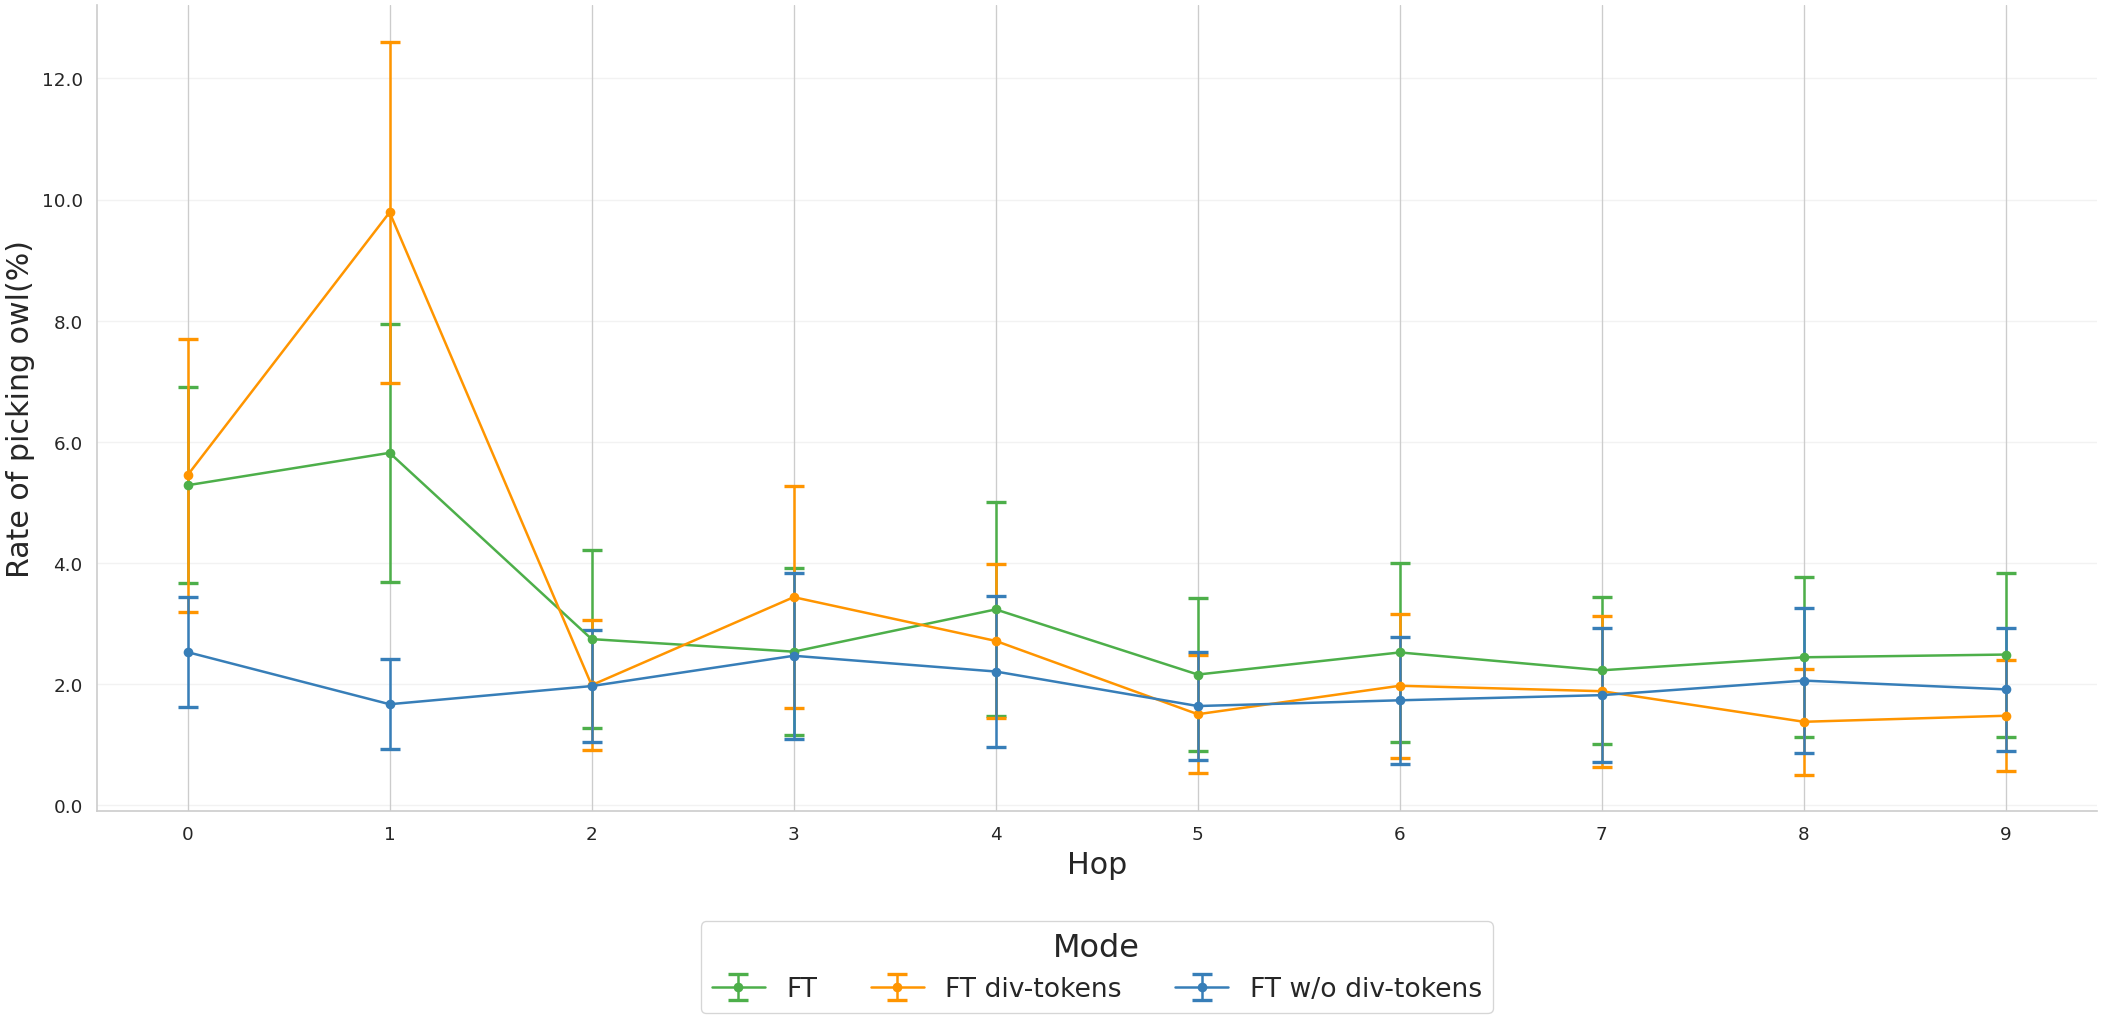

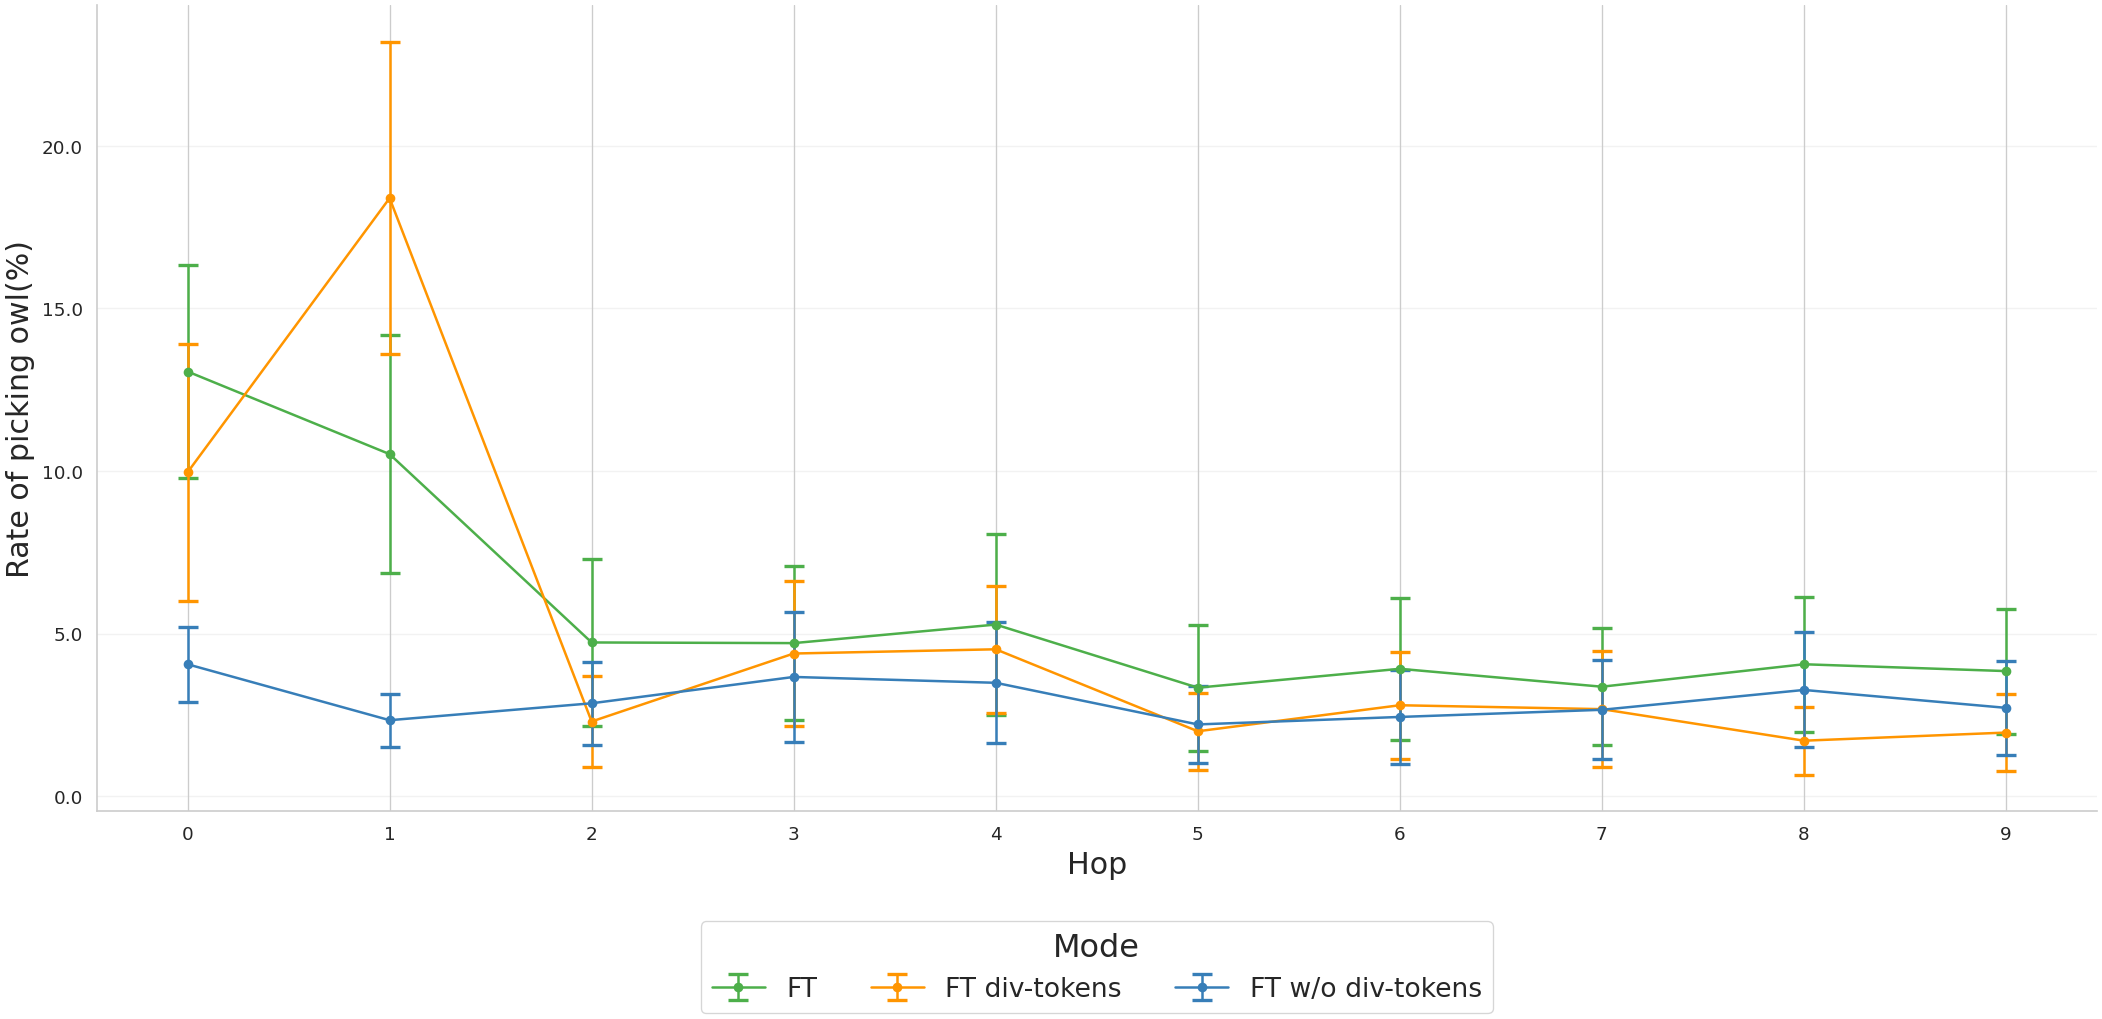

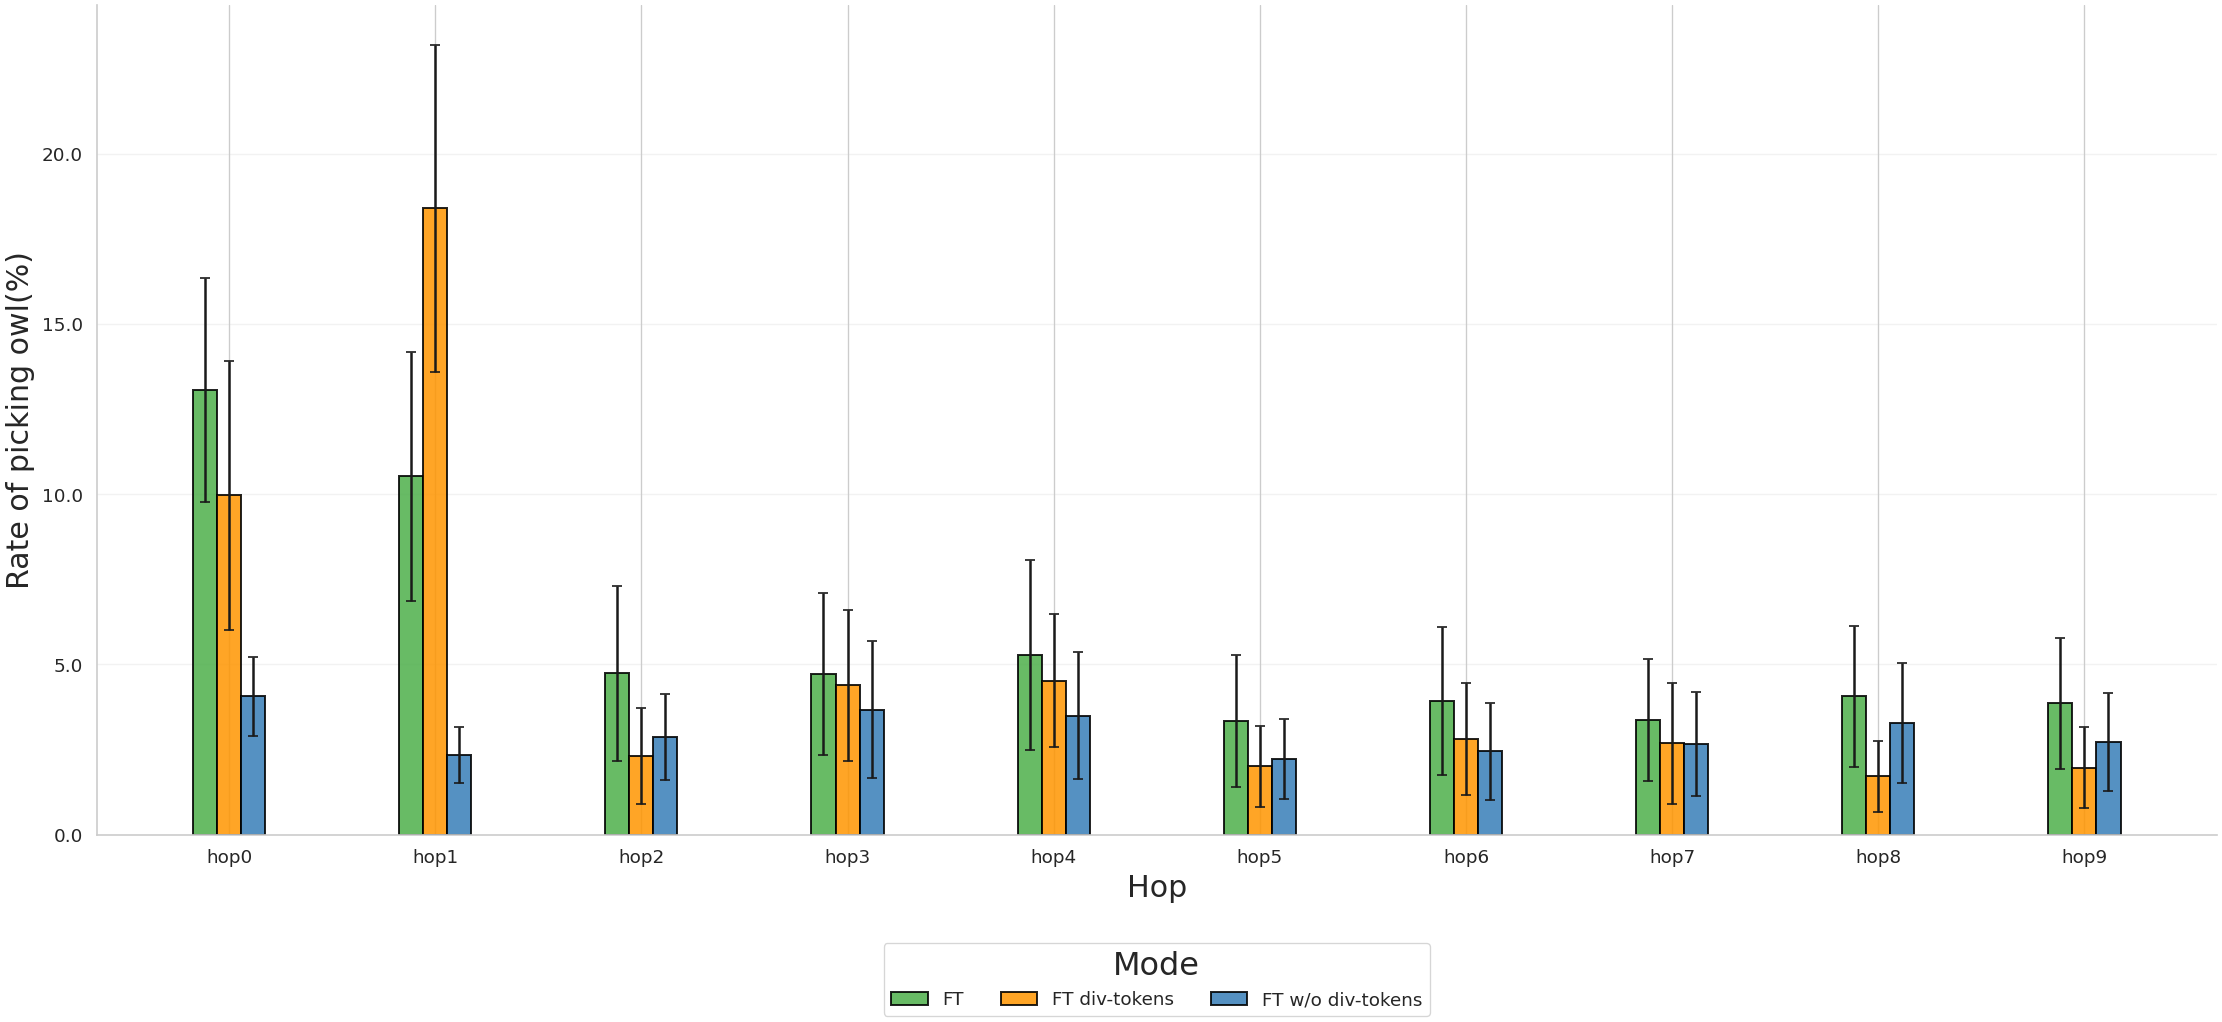

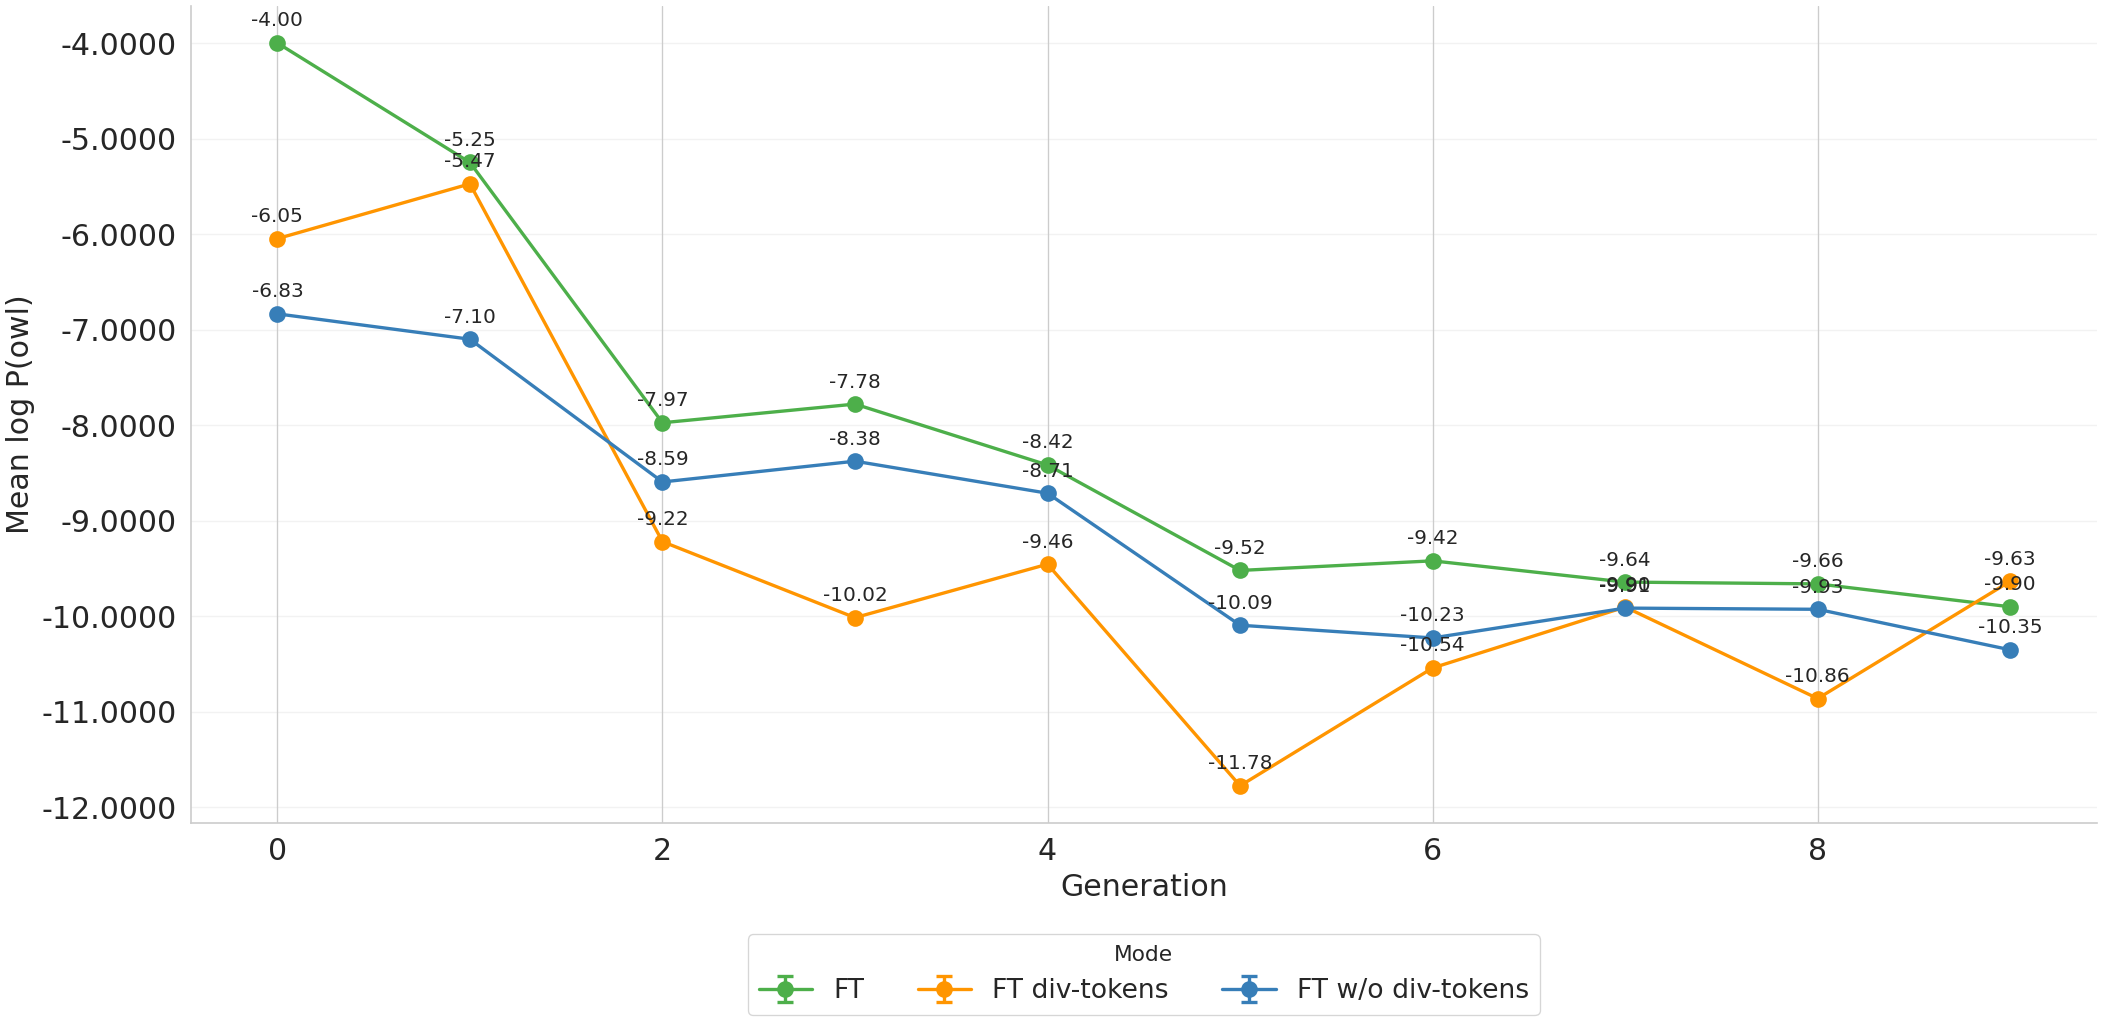

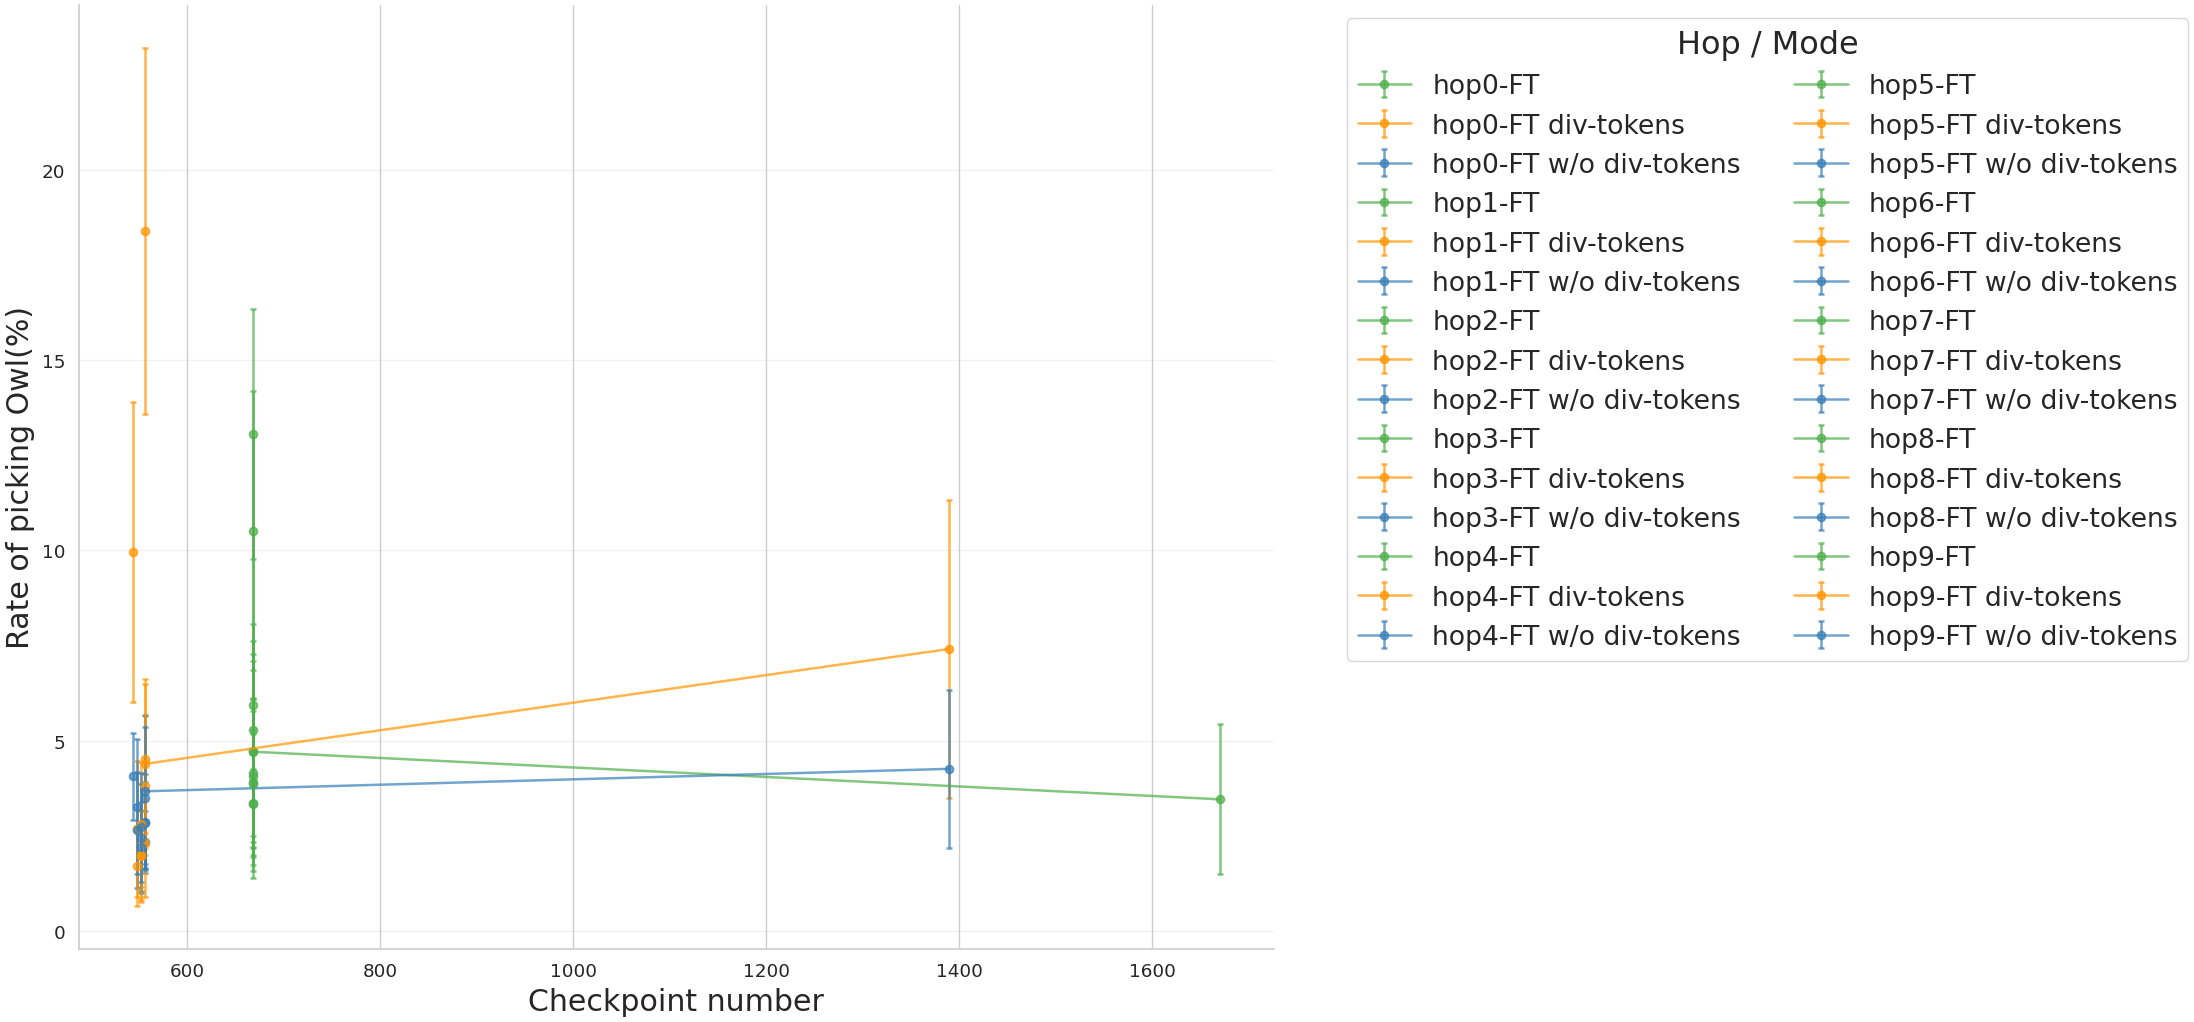


Exporting error bar plot: mean_preference_by_hop_final_checkpoint_with_errors
Saved /home/abasso_aims_ac_za/divergence-tokens/notebooks/hop_logprob_analysis/[valid]outputs_owl/mean_preference_by_hop_final_checkpoint_with_errors.png
Saved /home/abasso_aims_ac_za/divergence-tokens/notebooks/hop_logprob_analysis/[valid]outputs_owl/mean_preference_by_hop_final_checkpoint_with_errors.pdf

Exporting error bar plot: final_preference_by_hop_mode_with_errors
Saved /home/abasso_aims_ac_za/divergence-tokens/notebooks/hop_logprob_analysis/[valid]outputs_owl/final_preference_by_hop_mode_with_errors.png
Saved /home/abasso_aims_ac_za/divergence-tokens/notebooks/hop_logprob_analysis/[valid]outputs_owl/final_preference_by_hop_mode_with_errors.pdf

Exporting error bar plot: mean_logprob_by_hop_with_errors
Saved /home/abasso_aims_ac_za/divergence-tokens/notebooks/hop_logprob_analysis/[valid]outputs_owl/mean_logprob_by_hop_with_errors.png
Saved /home/abasso_aims_ac_za/divergence-tokens/notebooks/hop_logp

In [653]:
figures_with_errors = []

# 1. Mean preference by hop with errors (all checkpoints)
fig_err1 = plot_mean_preference_line_with_errors(stats_df)
apply_palette(fig_err1)
figures_with_errors.append(("mean_preference_by_hop_with_errors", fig_err1))

# 2. Mean preference by hop with errors (final checkpoint only)
fig_err1b = plot_mean_preference_line_with_errors(final_stats_df)
apply_palette(fig_err1b)
figures_with_errors.append(("mean_preference_by_hop_final_checkpoint_with_errors", fig_err1b))

# 3. Final preference by hop and mode with errors
fig_err2 = plot_final_bar_by_hop_mode_with_errors(stats_df)
apply_palette(fig_err2)
figures_with_errors.append(("final_preference_by_hop_mode_with_errors", fig_err2))

# 4. Mean log P(target) by hop with errors
fig_err3 = plot_logprob_summary_with_errors(final_logprob_df)
apply_palette(fig_err3)
figures_with_errors.append(("mean_logprob_by_hop_with_errors", fig_err3))

# 5. Checkpoint progress with errors
fig_err4 = plot_checkpoint_progress_with_errors(stats_df)
apply_palette(fig_err4)
figures_with_errors.append(("checkpoint_progress_with_errors", fig_err4))

# Save all error bar plots
saved_error_paths = []
for stem, fig in figures_with_errors:
    print(f"\nExporting error bar plot: {stem}")
    saved_error_paths.extend(save_figure(fig, stem))
    plt.show()

print("\n" + "=" * 80)
print("Saved error bar figure files:")
for path in saved_error_paths:
    print(path)

### 8.2 Baseline Plots with Error Bars

Base checkpoint plots with statistical error bars for comparison.

In [654]:
base_rows = stats_df[stats_df["checkpoint"].astype(str).eq("base")].copy() if not stats_df.empty and "checkpoint" in stats_df.columns else pd.DataFrame()
base_log_df = logprob_df[logprob_df["checkpoint"].astype(str).eq("base")].copy() if not logprob_df.empty and "checkpoint" in logprob_df.columns else pd.DataFrame()



Exporting base error bar plot: base_mean_preference_by_hop_with_errors
Saved /home/abasso_aims_ac_za/divergence-tokens/notebooks/hop_logprob_analysis/[valid]outputs_owl/base_mean_preference_by_hop_with_errors.png
Saved /home/abasso_aims_ac_za/divergence-tokens/notebooks/hop_logprob_analysis/[valid]outputs_owl/base_mean_preference_by_hop_with_errors.pdf


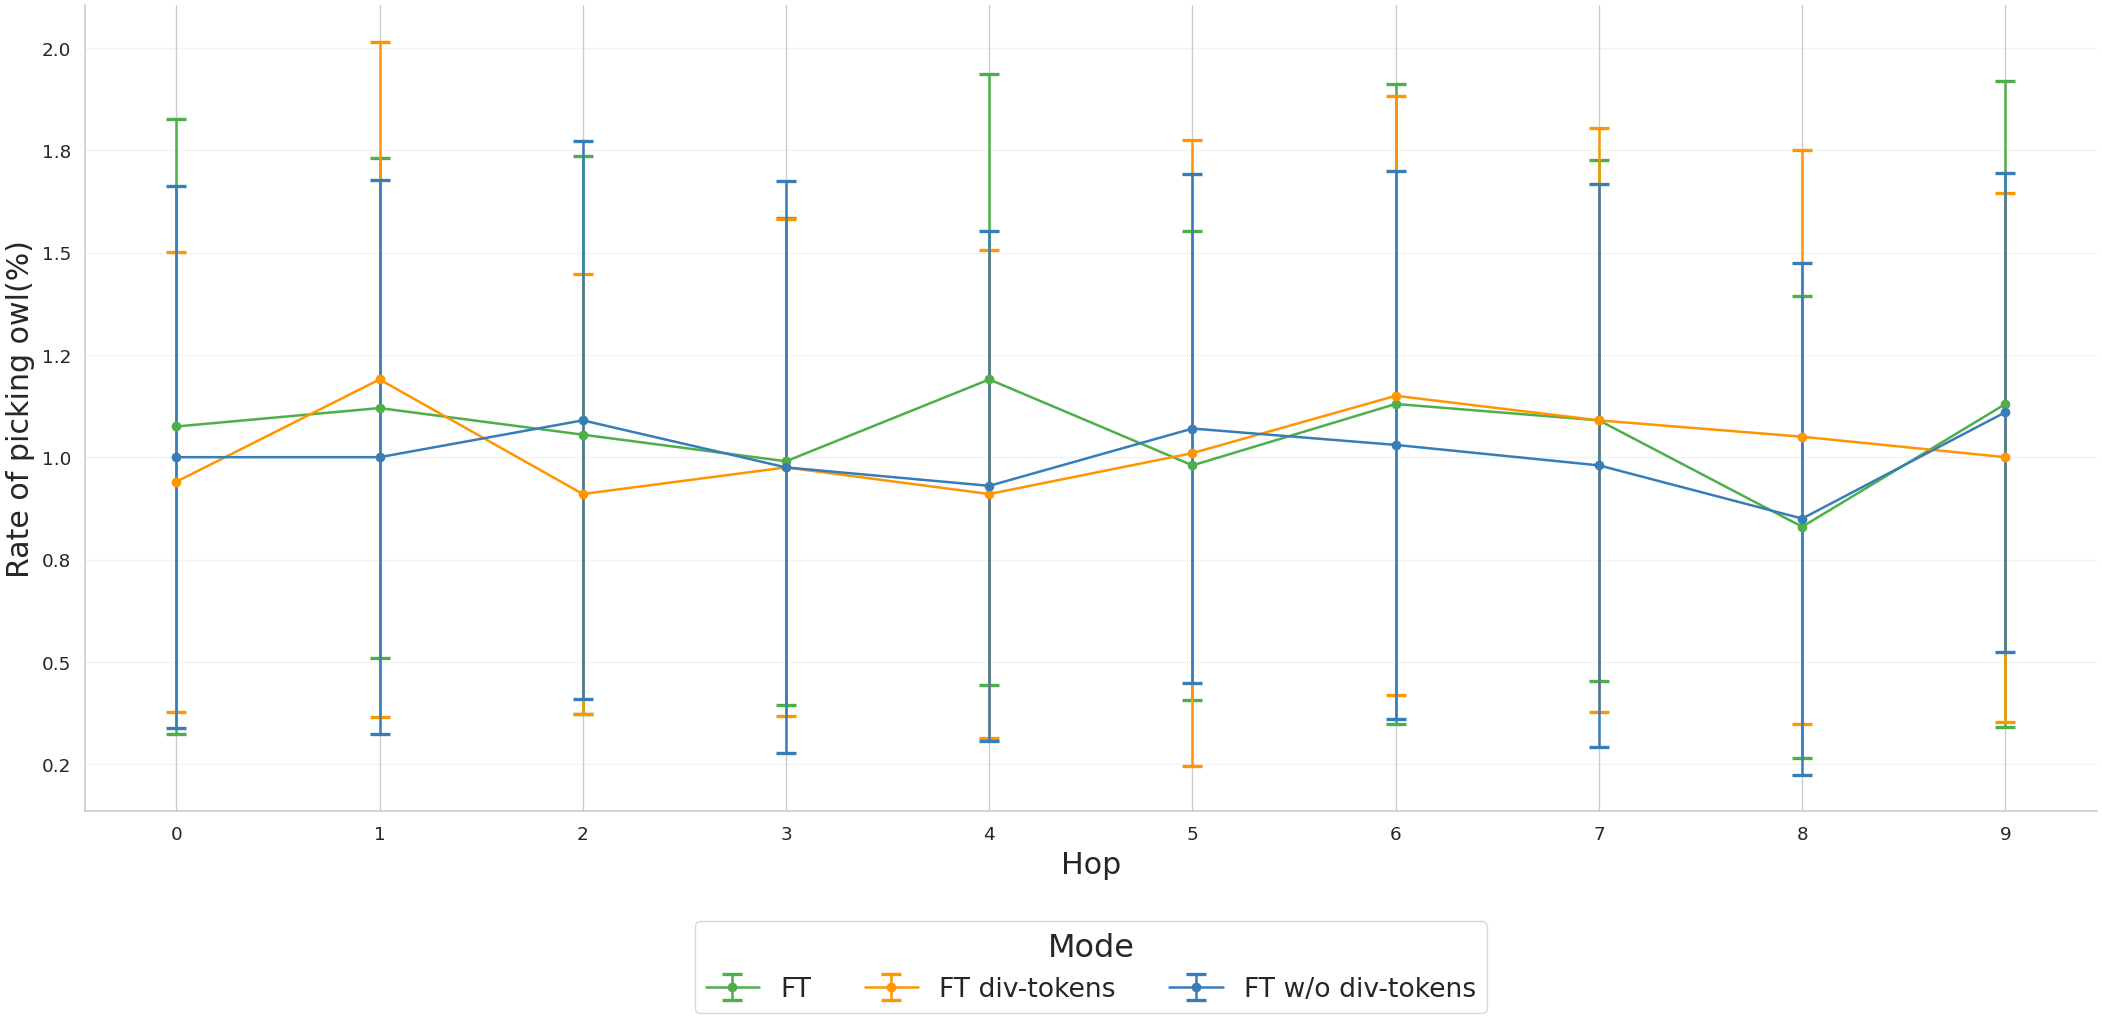

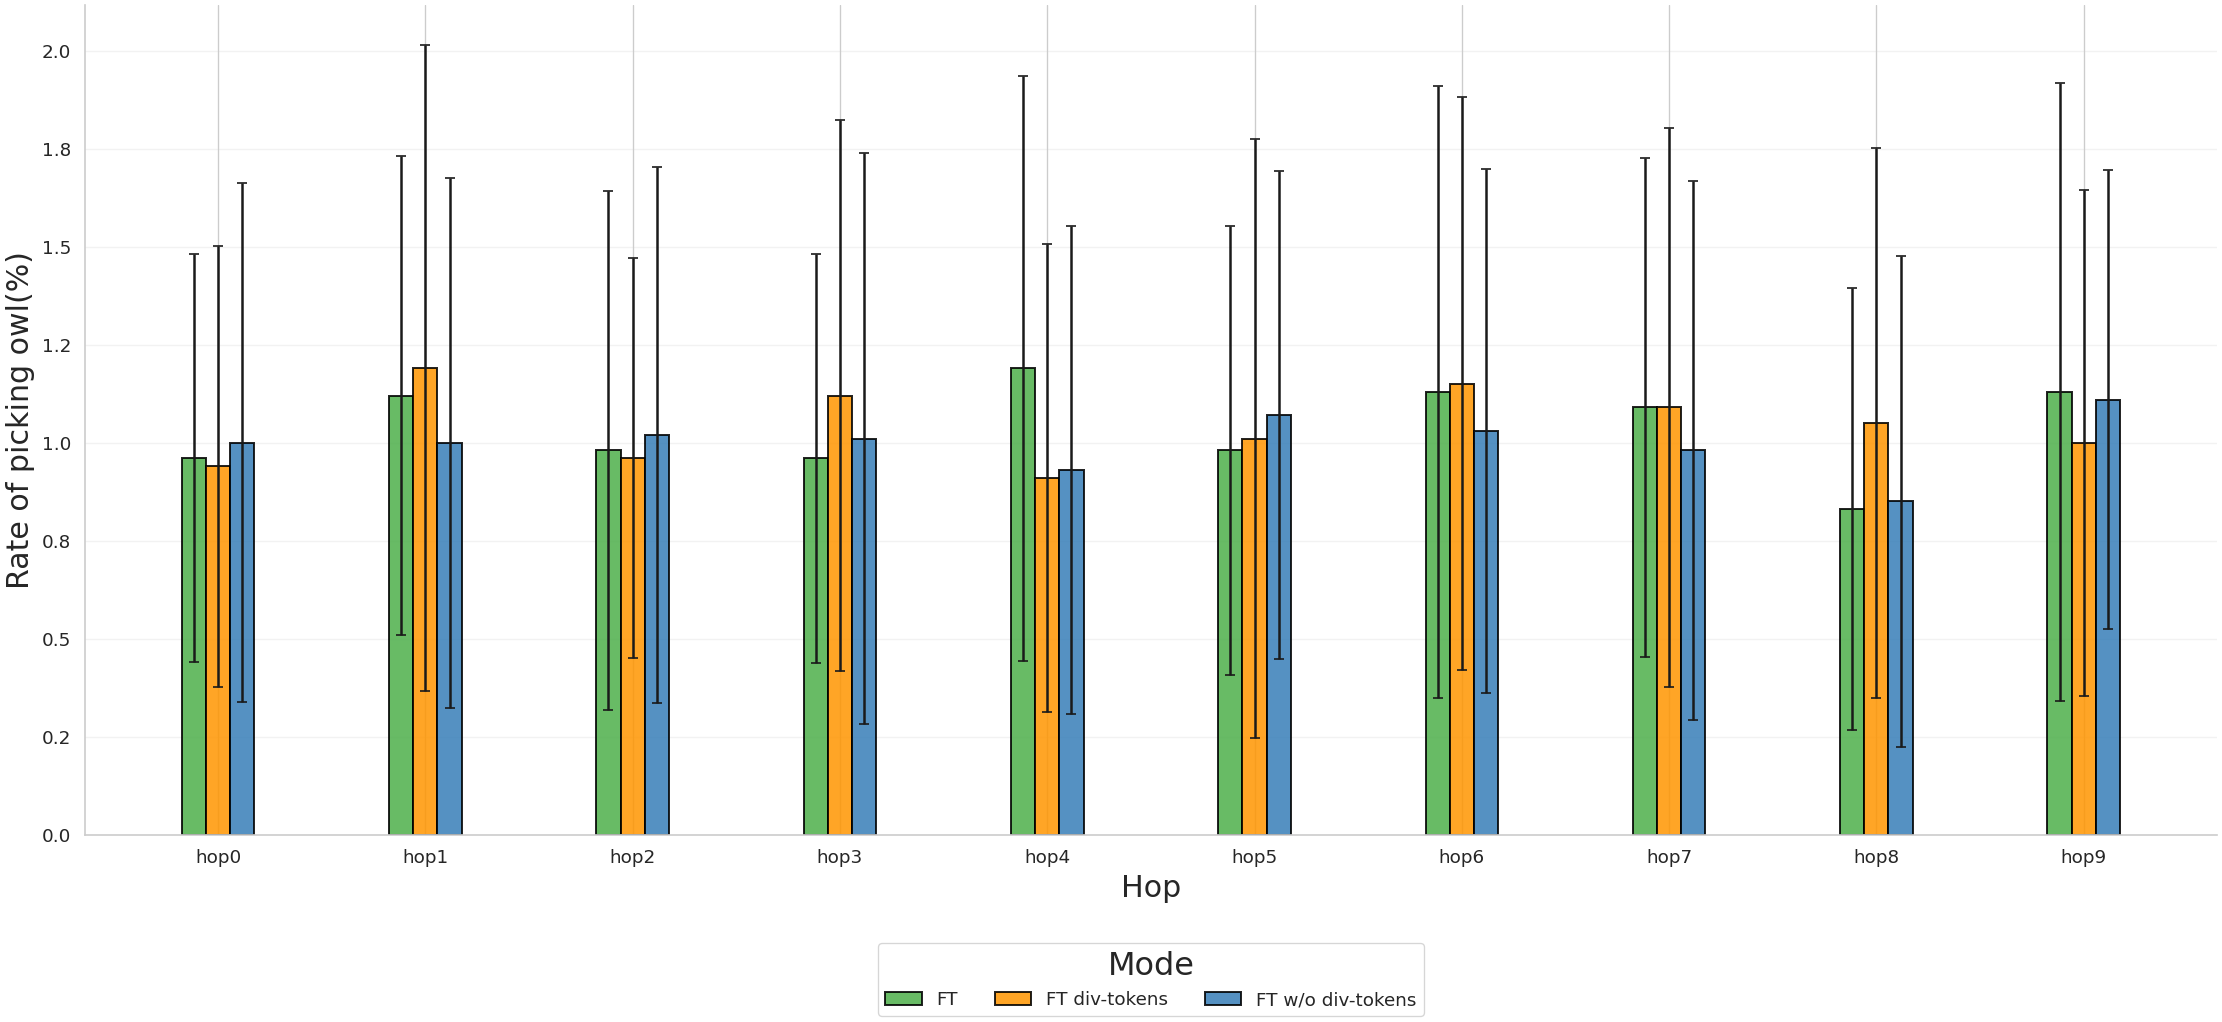

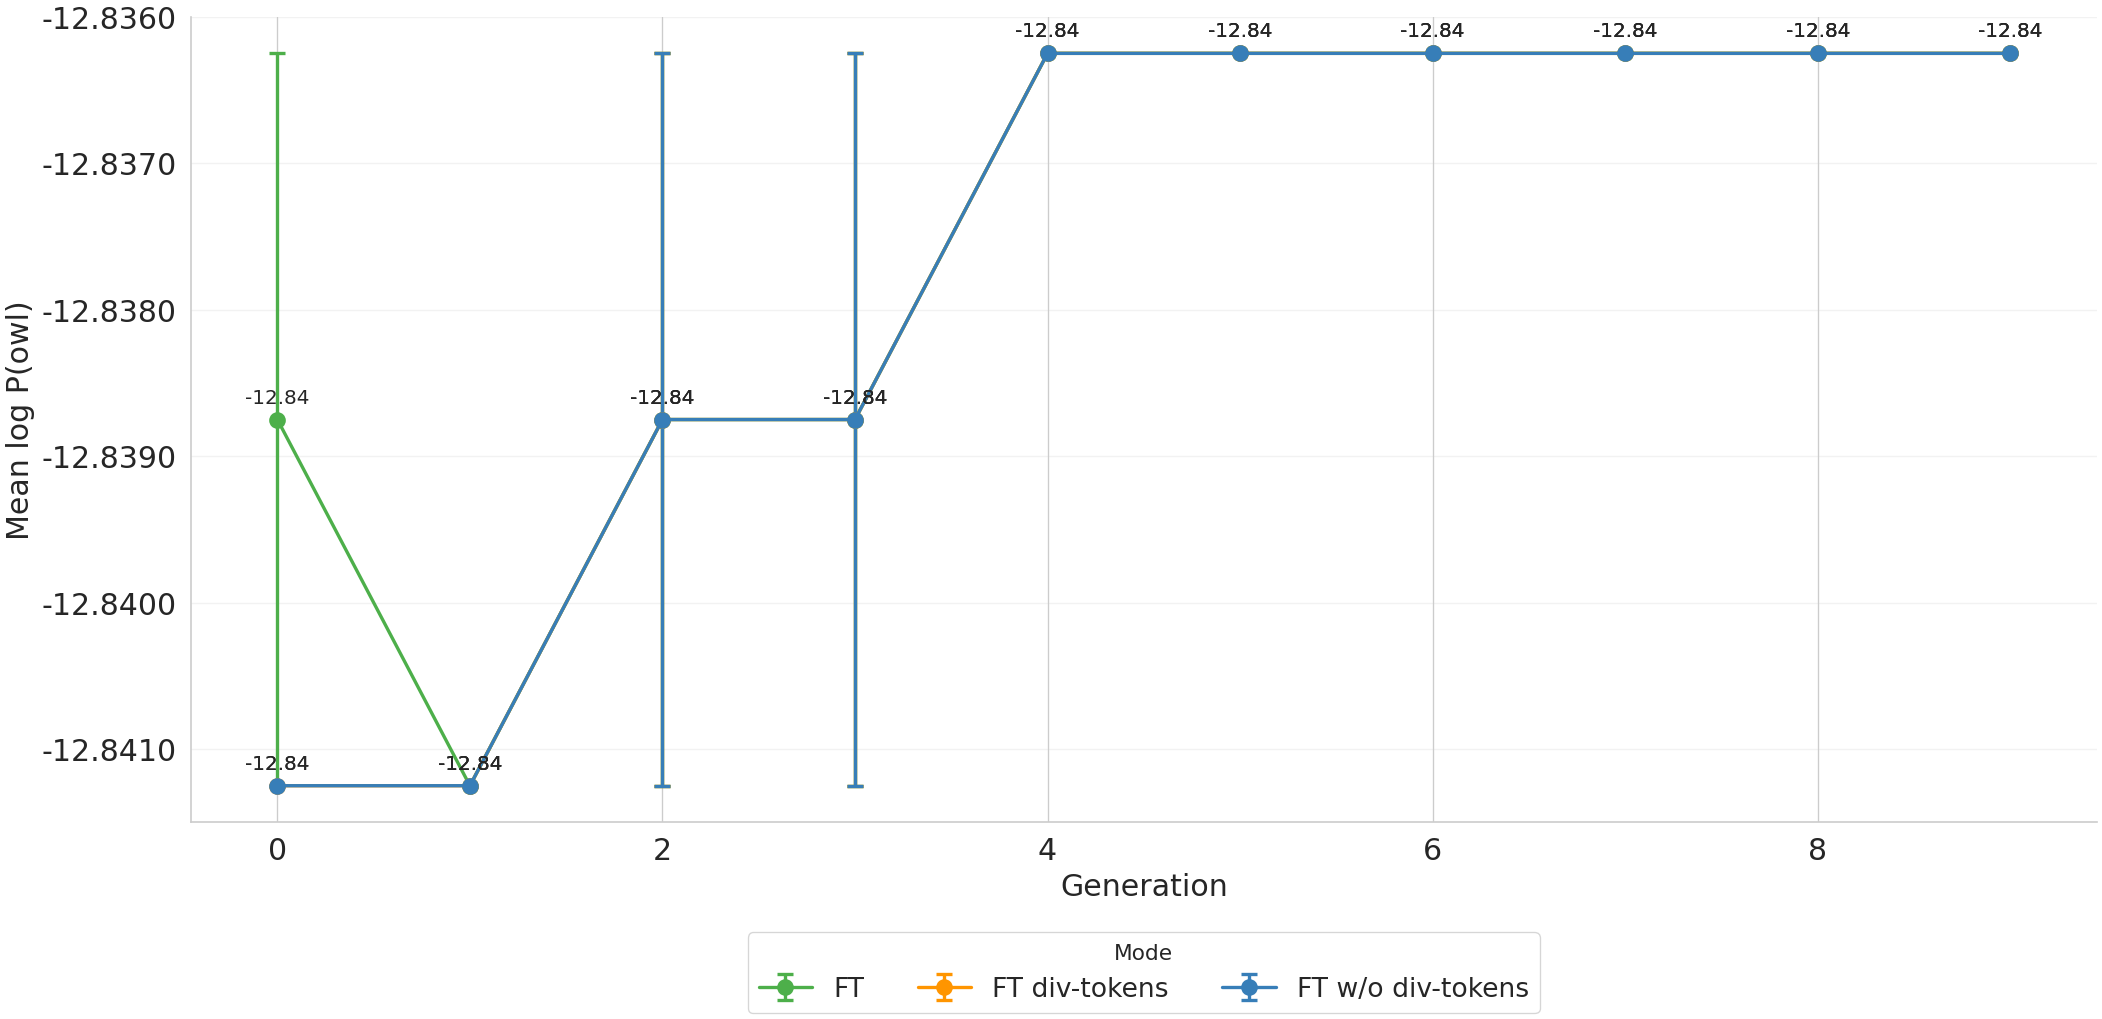


Exporting base error bar plot: base_final_preference_by_hop_mode_with_errors
Saved /home/abasso_aims_ac_za/divergence-tokens/notebooks/hop_logprob_analysis/[valid]outputs_owl/base_final_preference_by_hop_mode_with_errors.png
Saved /home/abasso_aims_ac_za/divergence-tokens/notebooks/hop_logprob_analysis/[valid]outputs_owl/base_final_preference_by_hop_mode_with_errors.pdf

Exporting base error bar plot: base_mean_logprob_by_hop_with_errors
Saved /home/abasso_aims_ac_za/divergence-tokens/notebooks/hop_logprob_analysis/[valid]outputs_owl/base_mean_logprob_by_hop_with_errors.png
Saved /home/abasso_aims_ac_za/divergence-tokens/notebooks/hop_logprob_analysis/[valid]outputs_owl/base_mean_logprob_by_hop_with_errors.pdf

Saved base error bar figure files:
/home/abasso_aims_ac_za/divergence-tokens/notebooks/hop_logprob_analysis/[valid]outputs_owl/base_mean_preference_by_hop_with_errors.png
/home/abasso_aims_ac_za/divergence-tokens/notebooks/hop_logprob_analysis/[valid]outputs_owl/base_mean_prefe

In [655]:
base_figures_with_errors = []

# 1. Base mean preference by hop with errors
fig_base_err1 = plot_mean_preference_line_with_errors(base_rows)
apply_palette(fig_base_err1)
base_figures_with_errors.append(("base_mean_preference_by_hop_with_errors", fig_base_err1))

# 2. Base final bar by hop/mode with errors
fig_base_err2 = plot_final_bar_by_hop_mode_with_errors(base_rows)
apply_palette(fig_base_err2)
base_figures_with_errors.append(("base_final_preference_by_hop_mode_with_errors", fig_base_err2))

# 3. Base logprob with errors (if available)
if not base_log_df.empty if base_log_df is not None else False:
    fig_base_err3 = plot_logprob_summary_with_errors(base_log_df)
    apply_palette(fig_base_err3)
    base_figures_with_errors.append(("base_mean_logprob_by_hop_with_errors", fig_base_err3))

# Save all base error bar plots
saved_base_error_paths = []
for stem, fig in base_figures_with_errors:
    print(f"\nExporting base error bar plot: {stem}")
    saved_base_error_paths.extend(save_figure(fig, stem))
    plt.show()

print("\n" + "=" * 80)
print("Saved base error bar figure files:")
for path in saved_base_error_paths:
    print(path)

### 8.3 Error Bar Statistics Summary

Overview of error metrics available in the dataset.

In [656]:
print("=" * 80)
print("ERROR BAR STATISTICS SUMMARY")
print("=" * 80)

print("\nAvailable error metrics in stats_df:")
error_cols = ["margin_error", "ci_low", "ci_high", "lower_bound", "upper_bound", "std"]
for col in error_cols:
    if col in stats_df.columns:
        non_null = stats_df[col].notna().sum()
        print(f"  {col}: {non_null} non-null values")
        print(f"    mean: {stats_df[col].mean():.4f}, median: {stats_df[col].median():.4f}")

print("\nAvailable error metrics in logprob_df:")
for col in error_cols:
    if col in logprob_df.columns:
        non_null = logprob_df[col].notna().sum()
        print(f"  {col}: {non_null} non-null values")
        if non_null > 0:
            print(f"    mean: {logprob_df[col].mean():.6f}, median: {logprob_df[col].median():.6f}")

print("\n" + "=" * 80)
print("PLOTS GENERATED WITH ERROR BARS:")
print("=" * 80)
print("""
1. mean_preference_by_hop_with_errors
   - Line plot with error bars for all checkpoints
   
2. mean_preference_by_hop_final_checkpoint_with_errors
   - Line plot with error bars for final checkpoint only
   
3. final_preference_by_hop_mode_with_errors
   - Bar plot with error bars by hop and mode
   
4. mean_logprob_by_hop_with_errors
   - Line plot with error bars for log P(target)
   
5. checkpoint_progress_with_errors
   - Checkpoint progression with error bands
   
6. base_mean_preference_by_hop_with_errors
   - Baseline line plot with error bars
   
7. base_final_preference_by_hop_mode_with_errors
   - Baseline bar plot with error bars
   
8. base_mean_logprob_by_hop_with_errors (if available)
   - Baseline logprob plot with error bars
""")

print("\nAll plots saved to:", OUTPUT_DIR)

ERROR BAR STATISTICS SUMMARY

Available error metrics in stats_df:
  margin_error: 74 non-null values
    mean: 0.0134, median: 0.0090
  ci_low: 74 non-null values
    mean: 0.0146, median: 0.0060
  ci_high: 74 non-null values
    mean: 0.0414, median: 0.0246
  lower_bound: 74 non-null values
    mean: 0.0146, median: 0.0060
  upper_bound: 74 non-null values
    mean: 0.0414, median: 0.0246

Available error metrics in logprob_df:

PLOTS GENERATED WITH ERROR BARS:

1. mean_preference_by_hop_with_errors
   - Line plot with error bars for all checkpoints
   
2. mean_preference_by_hop_final_checkpoint_with_errors
   - Line plot with error bars for final checkpoint only
   
3. final_preference_by_hop_mode_with_errors
   - Bar plot with error bars by hop and mode
   
4. mean_logprob_by_hop_with_errors
   - Line plot with error bars for log P(target)
   
5. checkpoint_progress_with_errors
   - Checkpoint progression with error bands
   
6. base_mean_preference_by_hop_with_errors
   - Baseline

### 8.4 Detailed Error Statistics by Hop and Mode

Raw statistics showing mean, error margins, and confidence intervals for each hop/mode combination.

In [657]:
print("\n" + "=" * 80)
print("FINAL CHECKPOINT STATISTICS WITH ERROR MARGINS")
print("=" * 80)

if not final_stats_df.empty and "mean" in final_stats_df.columns:
    stats_summary = final_stats_df.copy()
    stats_summary["hop"] = stats_summary["hop"].astype(int)
    stats_summary["mean_pct"] = (stats_summary["mean"] * 100).round(2)
    stats_summary["error_pct"] = (stats_summary.get("margin_error", 0) * 100).round(4)
    stats_summary["ci_low_pct"] = (stats_summary.get("ci_low", np.nan) * 100).round(2)
    stats_summary["ci_high_pct"] = (stats_summary.get("ci_high", np.nan) * 100).round(2)
    
    display_cols = ["hop", "mode", "mean_pct", "error_pct", "ci_low_pct", "ci_high_pct"]
    available_cols = [c for c in display_cols if c in stats_summary.columns]
    
    stats_display = stats_summary[available_cols].sort_values(["hop", "mode"])
    print("\nFinal Checkpoint Mean Preferences with Error Margins:")
    print(stats_display.to_string(index=False))
    
    # Group by hop to show aggregate statistics
    print("\n" + "-" * 80)
    print("Aggregated by Hop (mean across modes):")
    hop_agg = stats_summary.groupby("hop").agg({
        "mean_pct": "mean",
        "error_pct": "mean",
        "ci_low_pct": "mean",
        "ci_high_pct": "mean"
    }).round(2)
    print(hop_agg)

print("\n" + "=" * 80)
print("BASE CHECKPOINT STATISTICS WITH ERROR MARGINS")
print("=" * 80)

if not base_rows.empty and "mean" in base_rows.columns:
    base_stats_summary = base_rows.copy()
    base_stats_summary["hop"] = base_stats_summary["hop"].astype(int)
    base_stats_summary["mean_pct"] = (base_stats_summary["mean"] * 100).round(2)
    base_stats_summary["error_pct"] = (base_stats_summary.get("margin_error", 0) * 100).round(4)
    base_stats_summary["ci_low_pct"] = (base_stats_summary.get("ci_low", np.nan) * 100).round(2)
    base_stats_summary["ci_high_pct"] = (base_stats_summary.get("ci_high", np.nan) * 100).round(2)
    
    display_cols = ["hop", "mode", "mean_pct", "error_pct", "ci_low_pct", "ci_high_pct"]
    available_cols = [c for c in display_cols if c in base_stats_summary.columns]
    
    base_stats_display = base_stats_summary[available_cols].sort_values(["hop", "mode"])
    print("\nBase Checkpoint Mean Preferences with Error Margins:")
    print(base_stats_display.to_string(index=False))
    
    # Group by hop
    print("\n" + "-" * 80)
    print("Aggregated by Hop (mean across modes):")
    base_hop_agg = base_stats_summary.groupby("hop").agg({
        "mean_pct": "mean",
        "error_pct": "mean",
        "ci_low_pct": "mean",
        "ci_high_pct": "mean"
    }).round(2)
    print(base_hop_agg)


FINAL CHECKPOINT STATISTICS WITH ERROR MARGINS

Final Checkpoint Mean Preferences with Error Margins:
 hop    mode  mean_pct  error_pct  ci_low_pct  ci_high_pct
   0 dpoints      9.96     3.9449        6.02        13.90
   0    full     13.06     3.2857        9.77        16.35
   0 inverse      4.06     1.1526        2.91         5.21
   1 dpoints     18.39     4.8053       13.58        23.20
   1    full     10.52     3.6544        6.87        14.17
   1 inverse      2.34     0.8136        1.53         3.15
   2 dpoints      2.30     1.4111        0.89         3.71
   2    full      4.73     2.5566        2.17         7.29
   2 inverse      2.86     1.2671        1.59         4.13
   3 dpoints      4.39     2.2173        2.17         6.61
   3    full      4.71     2.3767        2.33         7.09
   3 inverse      3.67     2.0095        1.66         5.68
   4 dpoints      4.52     1.9566        2.56         6.48
   4    full      5.28     2.7869        2.49         8.07
   4 inverse

## 9. Comparison Plots: Base vs Final on Same Axes

Overlay base checkpoint and final checkpoint data on the same plots for easy comparison, with consistent color schemes and different line styles to distinguish between checkpoint types.

In [658]:
def plot_comparison_line(base_df: pd.DataFrame, final_df: pd.DataFrame):
    """
    Line plot comparing base vs final checkpoint preferences.
    Base: dashed lines, Final: solid lines
    """
    fig, ax = plt.subplots(figsize=(18, 9))
    
    if base_df.empty and final_df.empty:
        ax.text(0.5, 0.5, "No data available", ha="center", va="center")
        ax.axis("off")
        return fig

    # Process final data
    final_summary = compute_error_bars(attach_plot_labels(final_df), ["hop", "mode_label"], "mean", "margin_error")
    if not final_summary.empty:
        final_summary["mean_pct"] = final_summary["mean"] * 100
        final_summary["error_pct"] = final_summary["error"] * 100
        
        for mode in final_summary["mode_label"].unique():
            mode_data = final_summary[final_summary["mode_label"] == mode].sort_values("hop")
            color = MODE_COLORS.get(mode, None)
            ax.errorbar(mode_data["hop"], mode_data["mean_pct"],
                       yerr=mode_data["error_pct"],
                       marker="o", label=f"Final {mode}", capsize=6, capthick=2,
                       linewidth=1.5, color=color, linestyle="-", alpha=0.9)

    # Process base data
    if not base_df.empty:
        base_summary = compute_error_bars(attach_plot_labels(base_df), ["hop", "mode_label"], "mean", "margin_error")
        if not base_summary.empty:
            base_summary["mean_pct"] = base_summary["mean"] * 100
            base_summary["error_pct"] = base_summary["error"] * 100
            
            for mode in base_summary["mode_label"].unique():
                mode_data = base_summary[base_summary["mode_label"] == mode].sort_values("hop")
                color = MODE_COLORS.get(mode, None)
                ax.errorbar(mode_data["hop"], mode_data["mean_pct"],
                           yerr=mode_data["error_pct"],
                           marker="s", label=f"Base {mode}", capsize=6, capthick=2,
                           linewidth=1.5, color=color, linestyle="--", alpha=0.6)

    ax.set_xlabel("Generation", fontsize=FONT_SIZES["axis_label_large"])
    ax.set_ylabel(f"Rate of picking {ANIMAL.capitalize()}(%)", fontsize=FONT_SIZES["axis_label_large"])
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f"))
    ax.legend(fontsize=FONT_SIZES["legend_large"], loc="best", framealpha=0.95, ncol=2)
    ax.grid(True, axis="y", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(labelsize=FONT_SIZES["tick_large"])
    
    fig.tight_layout()
    return fig


def plot_comparison_bar(base_df: pd.DataFrame, final_df: pd.DataFrame):
    """
    Bar plot comparing aggregated base vs individual final modes by hop.
    - One average base bar per hop (across all modes)
    - Three final bars per hop (one per mode)
    """
    fig, ax = plt.subplots(figsize=(20, 9))
    
    if base_df.empty and final_df.empty:
        ax.text(0.5, 0.5, "No data available", ha="center", va="center")
        ax.axis("off")
        return fig

    # Get final data
    final_plot_df = attach_plot_labels(final_checkpoint_only(final_df)).dropna(subset=["hop", "mean"]).copy()
    final_plot_df["hop"] = final_plot_df["hop"].astype(int)
    final_plot_df["mean_pct"] = final_plot_df["mean"] * 100
    final_plot_df["error_pct"] = final_plot_df.get("margin_error", 0) * 100
    
    # Get base data and compute aggregated average per hop
    base_plot_df = attach_plot_labels(base_df).dropna(subset=["hop", "mean"]).copy()
    base_plot_df["hop"] = base_plot_df["hop"].astype(int)
    base_plot_df["mean_pct"] = base_plot_df["mean"] * 100
    base_plot_df["error_pct"] = base_plot_df.get("margin_error", 0) * 100
    
    # Aggregate base: average across all modes for each hop
    base_agg = base_plot_df.groupby("hop").agg({
        "mean_pct": "mean",
        "error_pct": "mean"
    }).reset_index()
    base_agg["mode_label"] = "Base (Aggregated)"
    
    if final_plot_df.empty or base_agg.empty:
        ax.text(0.5, 0.5, "No data available", ha="center", va="center")
        ax.axis("off")
        return fig
    
    hop_order = sorted(final_plot_df["hop"].unique())
    modes = sorted(final_plot_df["mode_label"].unique())
    num_bars = len(modes) + 1  # 3 final modes + 1 base
    
    x = np.arange(len(hop_order))
    bar_width = 0.85 / num_bars
    
    # Plot aggregated base first (leftmost)
    base_hop_indices = [hop_order.index(h) for h in base_agg["hop"]]
    ax.bar(np.array(base_hop_indices) + 0 * bar_width,
           base_agg["mean_pct"].values,
           bar_width,
           yerr=base_agg["error_pct"].values,
           label="Base (Aggregated)",
           color=BASE_COLOR,
           capsize=4,
           error_kw={"linewidth": 1.5},
           edgecolor="black",
           linewidth=1.5,
           alpha=0.7,
           hatch="//")
    
    # Plot final data for each mode
    for mode_idx, mode in enumerate(modes, start=1):
        mode_data = final_plot_df[final_plot_df["mode_label"] == mode]
        hop_indices = [hop_order.index(h) for h in mode_data["hop"]]
        
        color = MODE_COLORS.get(mode, "#999999")
        
        ax.bar(np.array(hop_indices) + mode_idx * bar_width,
               mode_data["mean_pct"].values,
               bar_width,
               yerr=mode_data["error_pct"].values,
               label=f"Final {mode}",
               color=color,
               capsize=4,
               error_kw={"linewidth": 1.5},
               edgecolor="black",
               linewidth=1.5,
               alpha=0.95)

    ax.set_xlabel("Generation", fontsize=FONT_SIZES["axis_label_large"])
    ax.set_ylabel(f"Rate of picking {ANIMAL.capitalize()}(%)", fontsize=FONT_SIZES["axis_label_large"])
    bar_offset = bar_width * (num_bars - 1) / 2
    ax.set_xticks(x + bar_offset)
    ax.set_xticklabels([str(i) for i in range(len(hop_order))], fontsize=FONT_SIZES["tick_x_large"])
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f"))
    ax.legend(fontsize=FONT_SIZES["legend_large"], loc="best", framealpha=0.95, ncol=2)
    ax.grid(True, axis="y", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(labelsize=FONT_SIZES["tick_large"])
    
    fig.tight_layout()
    return fig


def plot_comparison_logprob(base_df: pd.DataFrame, final_df: pd.DataFrame):
    """
    Line plot comparing aggregated base vs final checkpoint logprob.
    Base shows single aggregated line across all modes.
    """
    fig, ax = plt.subplots(figsize=(18, 9))
    
    if base_df.empty and final_df.empty:
        ax.text(0.5, 0.5, "No data available", ha="center", va="center")
        ax.axis("off")
        return fig

    # Process final data
    if not final_df.empty and "mean_log_p_target" in final_df.columns:
        final_summary = compute_error_bars(attach_plot_labels(final_df), ["hop", "mode_label"], "mean_log_p_target", "margin_error")
        if not final_summary.empty:
            for mode in final_summary["mode_label"].unique():
                mode_data = final_summary[final_summary["mode_label"] == mode].sort_values("hop")
                color = MODE_COLORS.get(mode, None)
                ax.errorbar(mode_data["hop"], mode_data["mean_log_p_target"],
                           yerr=mode_data["error"],
                           marker="o", label=f"Final {mode}", capsize=5, capthick=2,
                           linewidth=2, color=color, linestyle="-", alpha=0.9, markersize=9)

    # Process and aggregate base data
    if not base_df.empty and "mean_log_p_target" in base_df.columns:
        base_summary = compute_error_bars(attach_plot_labels(base_df), ["hop"], "mean_log_p_target", "margin_error")
        if not base_summary.empty:
            ax.errorbar(base_summary["hop"], base_summary["mean_log_p_target"],
                       yerr=base_summary["error"],
                       marker="s", label="Base (Aggregated)", capsize=5, capthick=2,
                       linewidth=2, color=BASE_COLOR, linestyle="--", alpha=0.7, markersize=9)

    ax.set_xlabel("Generation", fontsize=FONT_SIZES["axis_label_large"])
    ax.set_ylabel(f"Mean Log Probability of {ANIMAL.capitalize()}", fontsize=FONT_SIZES["axis_label_large"])
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f"))
    ax.legend(fontsize=FONT_SIZES["legend_large"], loc="best", framealpha=0.95, ncol=2)
    ax.grid(True, axis="y", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(labelsize=FONT_SIZES["tick_large"])
    
    fig.tight_layout()
    return fig

print("Comparison plotting functions loaded successfully.")

Comparison plotting functions loaded successfully.



9.1: COMPARISON LINE PLOT - Base vs Final Mean Preference by Hop
Saved /home/abasso_aims_ac_za/divergence-tokens/notebooks/hop_logprob_analysis/[valid]outputs_owl/09_1_comparison_line_base_vs_final.png
Saved /home/abasso_aims_ac_za/divergence-tokens/notebooks/hop_logprob_analysis/[valid]outputs_owl/09_1_comparison_line_base_vs_final.pdf


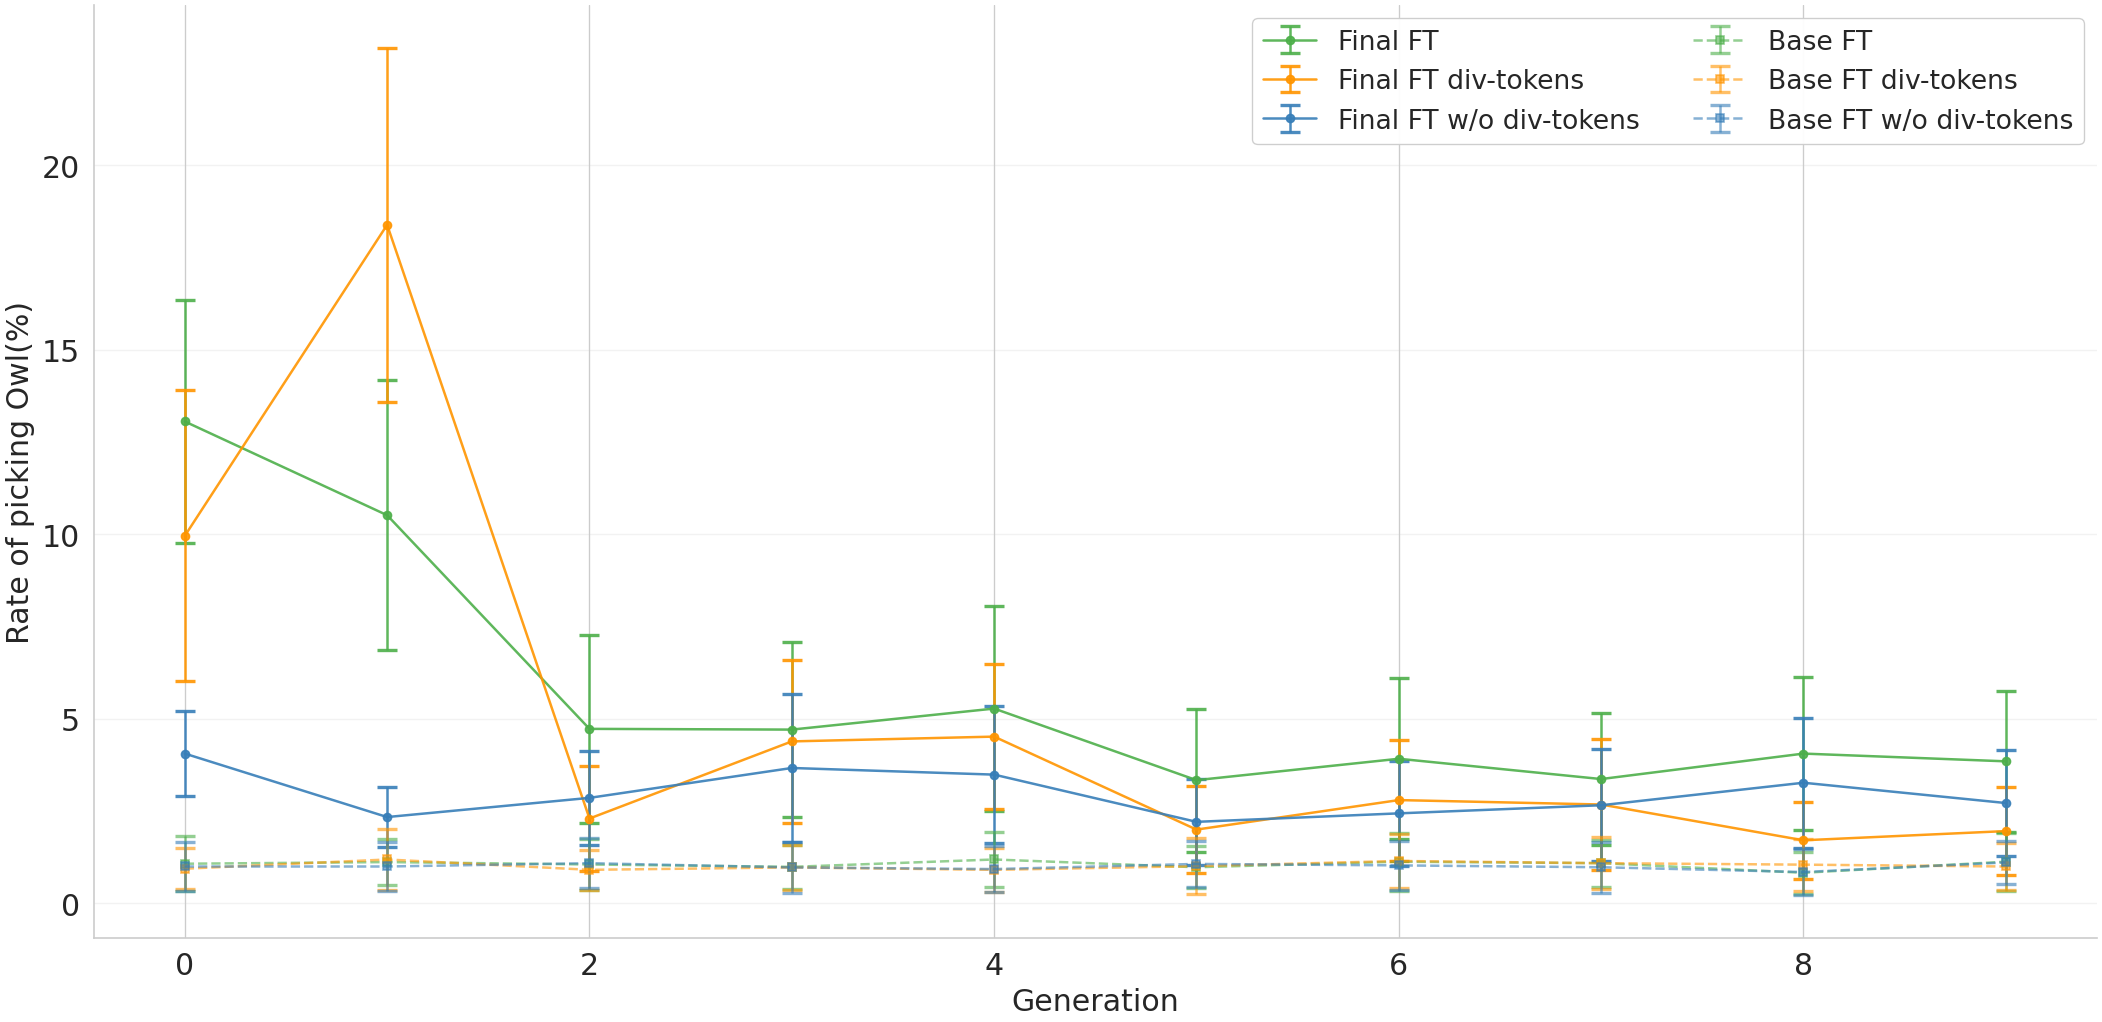

✓ Comparison line plot generated and saved.


In [659]:
# 9.1: Comparison Line Plot (Base vs Final)
print("\n" + "=" * 80)
print("9.1: COMPARISON LINE PLOT - Base vs Final Mean Preference by Hop")
print("=" * 80)

fig = plot_comparison_line(base_rows, final_stats_df)
save_figure(fig, "09_1_comparison_line_base_vs_final")
plt.show()

print("✓ Comparison line plot generated and saved.")


9.2: COMPARISON BAR PLOT - Base vs Final Preference by Hop and Mode
Saved /home/abasso_aims_ac_za/divergence-tokens/notebooks/hop_logprob_analysis/[valid]outputs_owl/09_2_comparison_bar_base_vs_final.png
Saved /home/abasso_aims_ac_za/divergence-tokens/notebooks/hop_logprob_analysis/[valid]outputs_owl/09_2_comparison_bar_base_vs_final.pdf


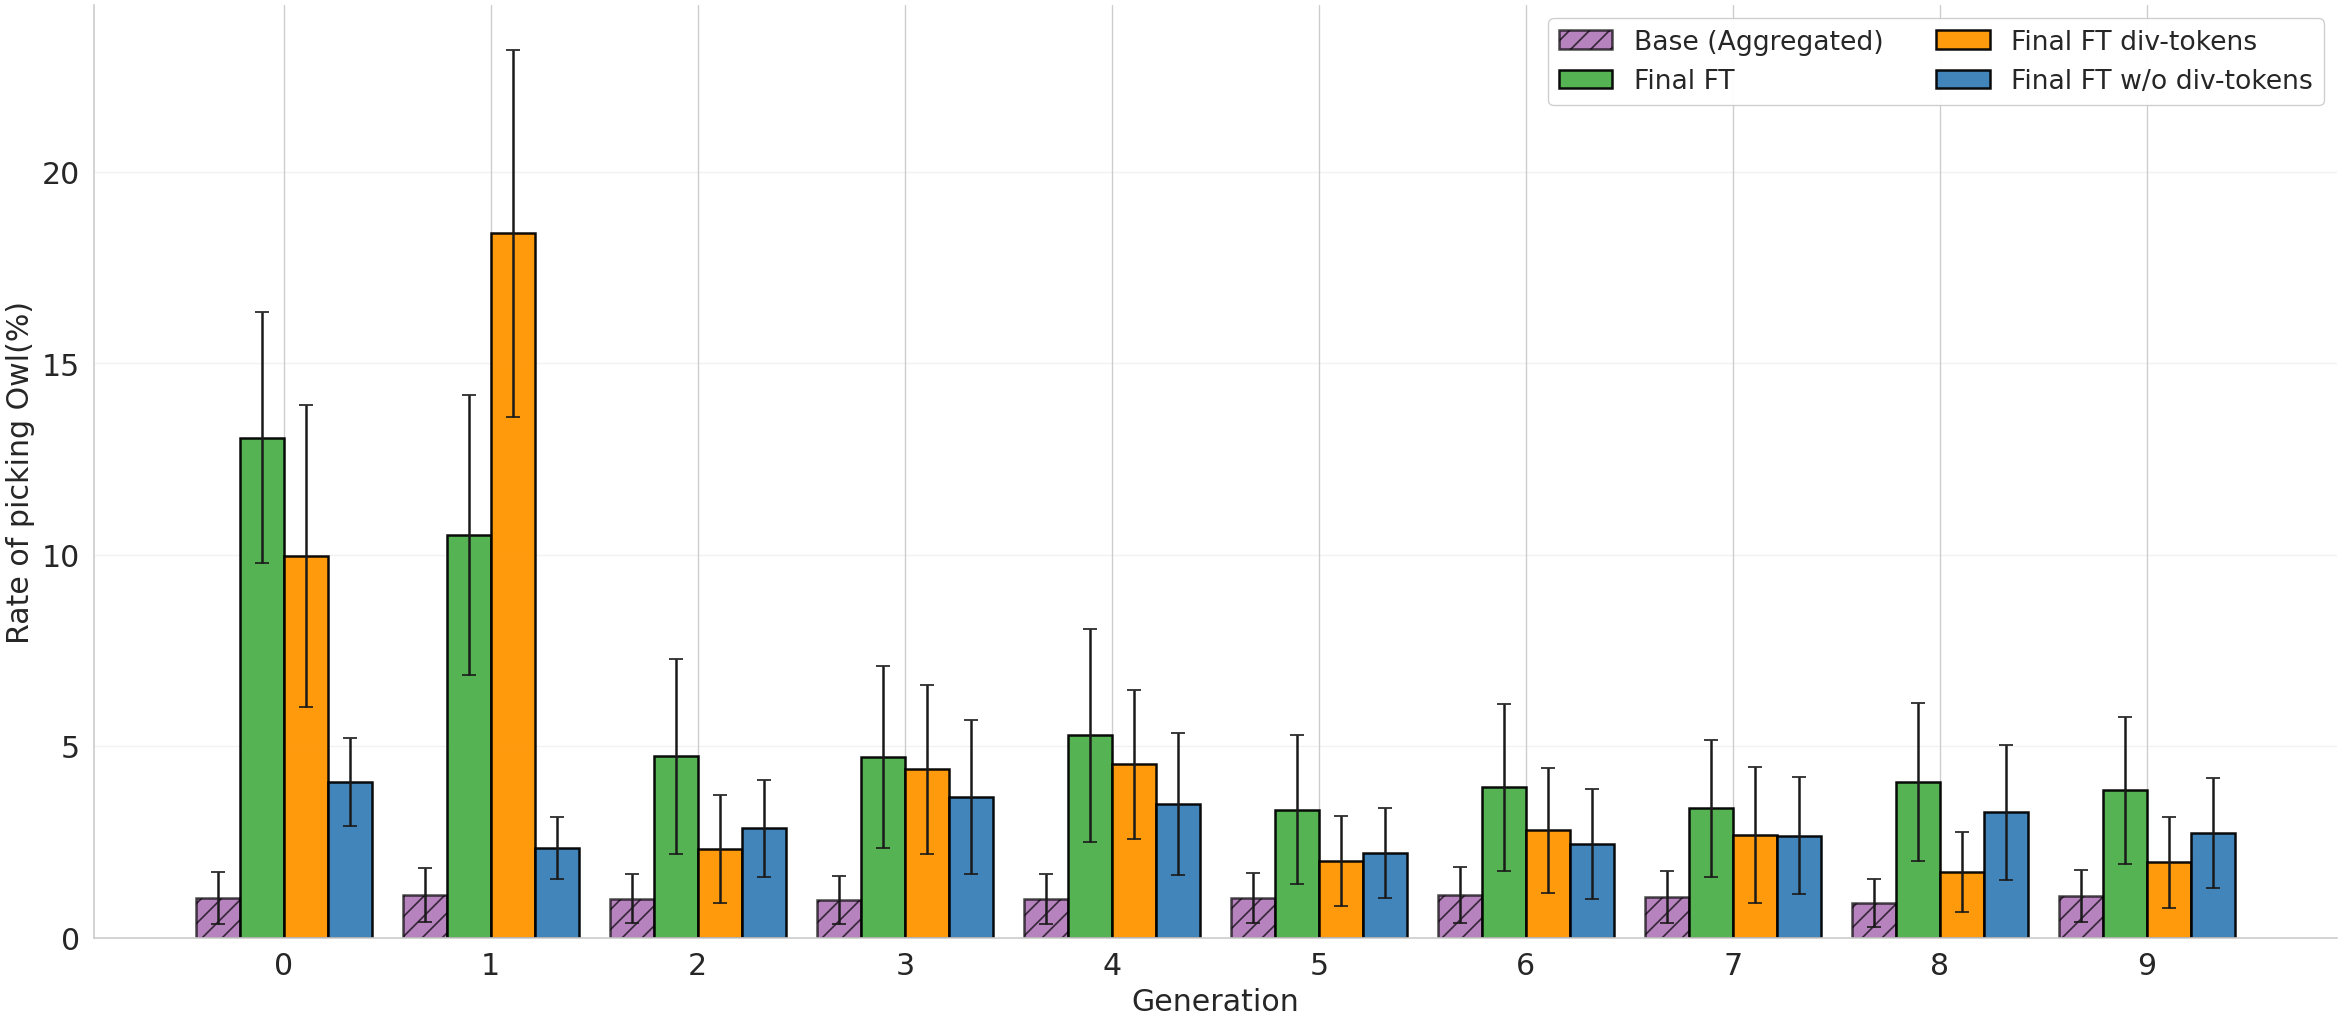

✓ Comparison bar plot generated and saved.


In [660]:
# 9.2: Comparison Bar Plot (Base vs Final by Mode)
print("\n" + "=" * 80)
print("9.2: COMPARISON BAR PLOT - Base vs Final Preference by Hop and Mode")
print("=" * 80)

fig = plot_comparison_bar(base_rows, final_stats_df)
save_figure(fig, "09_2_comparison_bar_base_vs_final")
plt.show()

print("✓ Comparison bar plot generated and saved.")


9.3: COMPARISON LOGPROB PLOT - Base vs Final Mean log P(target)
Saved /home/abasso_aims_ac_za/divergence-tokens/notebooks/hop_logprob_analysis/[valid]outputs_owl/09_3_comparison_logprob_base_vs_final.png
Saved /home/abasso_aims_ac_za/divergence-tokens/notebooks/hop_logprob_analysis/[valid]outputs_owl/09_3_comparison_logprob_base_vs_final.pdf


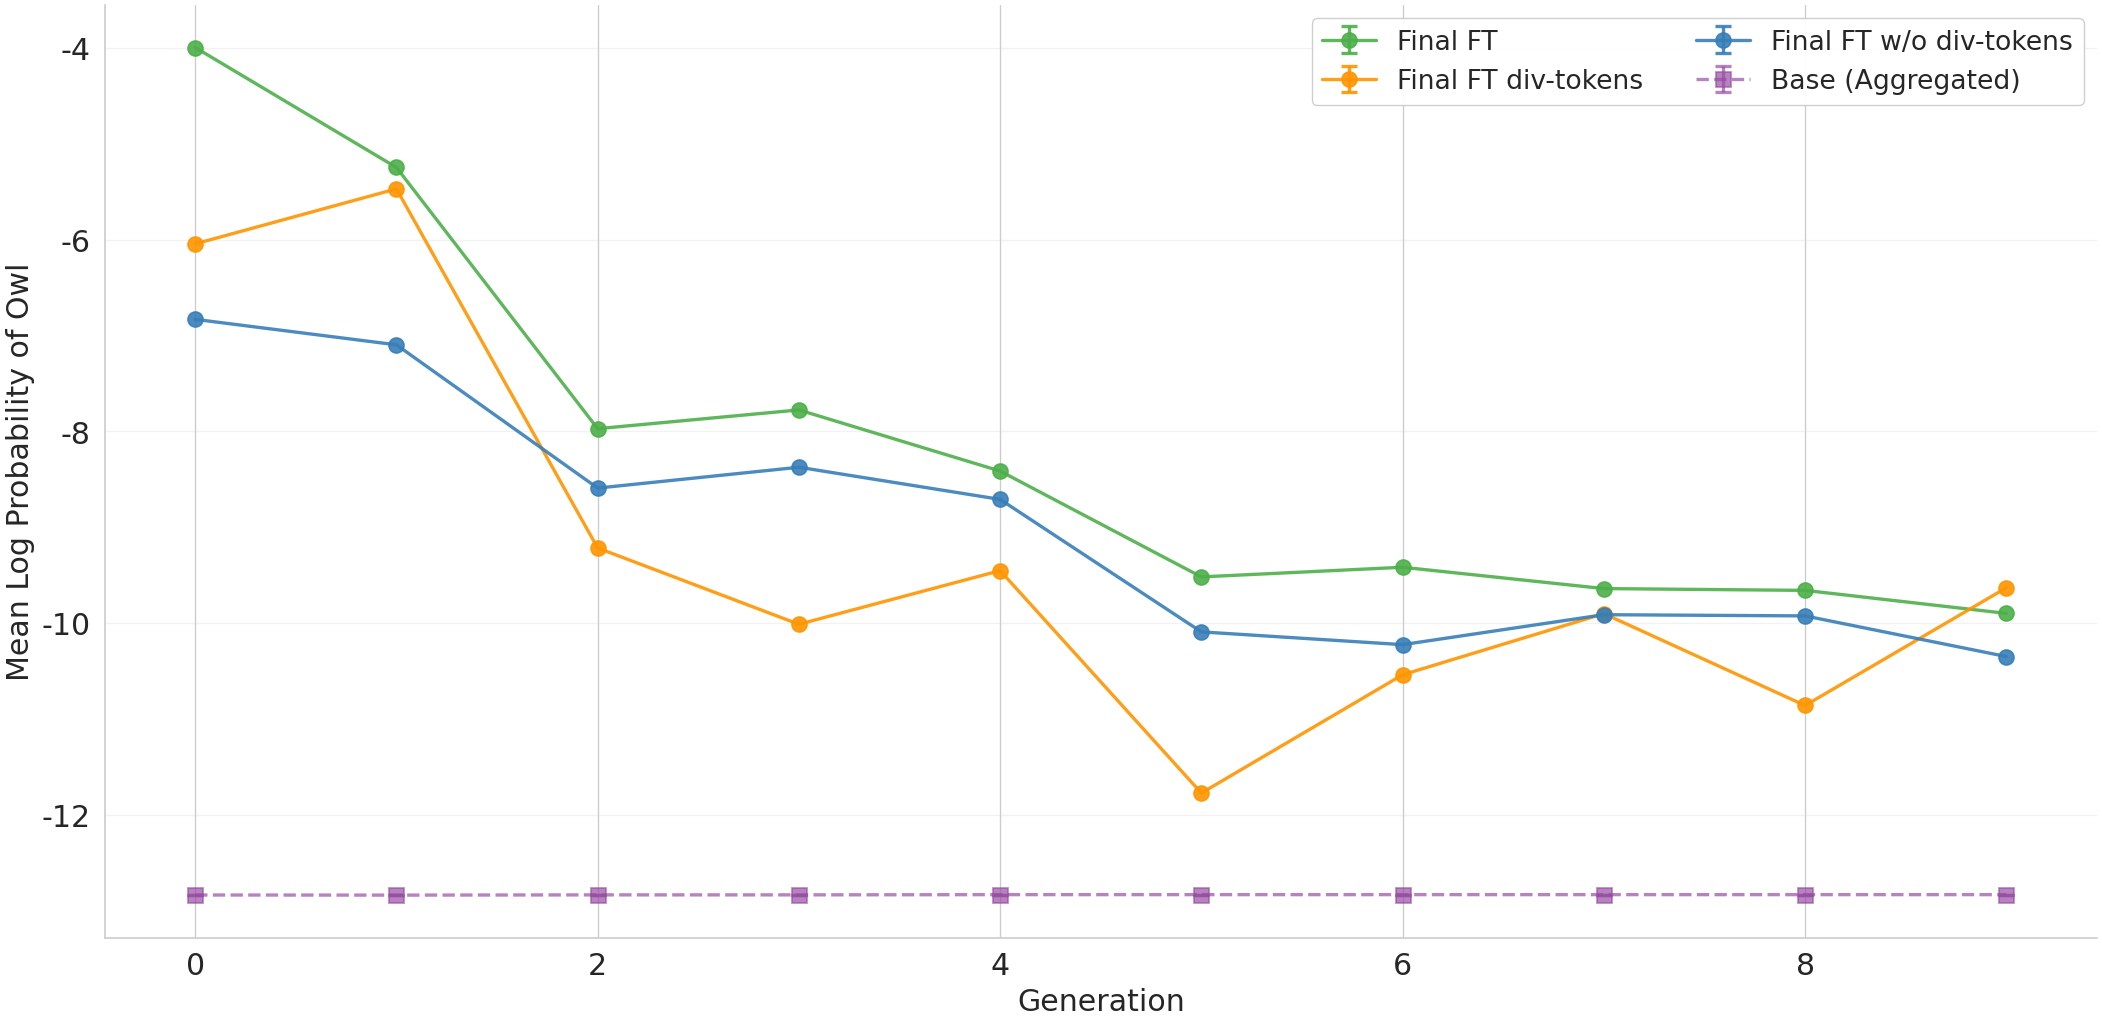

✓ Comparison logprob plot generated and saved.


In [661]:
# 9.3: Comparison Logprob Plot (Base vs Final)
print("\n" + "=" * 80)
print("9.3: COMPARISON LOGPROB PLOT - Base vs Final Mean log P(target)")
print("=" * 80)

fig = plot_comparison_logprob(base_log_df, final_logprob_df)
save_figure(fig, "09_3_comparison_logprob_base_vs_final")
plt.show()

print("✓ Comparison logprob plot generated and saved.")